<a href="https://colab.research.google.com/github/nashlypilar-collab/Intro_ciencia_tarea_grupo/blob/main/FraudesTDC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Carga y Lectura del DataFrame**

In [493]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

df = pd.read_csv("/content/credit_card_fraud_2026.csv")

duckdb.register("transacciones", df)
import sqlite3
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [494]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

In [495]:
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,is_new_merchant,used_vpn,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,22.35,39,25,1080.71,False,False,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,35.28,47,33,4463.72,True,False,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,9.82,51,59,366.25,False,True,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,19.72,48,28,1345.29,True,False,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,17.68,43,36,4192.59,False,False,False,False,0,3.9,2,4,False,32.7,0,0


**Listado de Variables e identificación de Tipo**

CATEGÓRICAS / NOMINALES:

- transaction_id
- merchant_category
- card_type
- auth_method
- channel
- device_type


ORDINALES:


NUMÉRICAS:
- amount_usd
- hours_since_last_txn
- txn_count_last_24h
- distance_from_home_km
- card_age_months
- customer_age
- account_balance_usd


BOOLEANAS:
- is_foreign_transaction
- is_new_merchant
- used_vpn
- ip_country_mismatch
- billing_shipping_mismatch
- billing_shipping_mismatch


In [496]:
df.select_dtypes(include=['number']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         20000 non-null  int64  
 1   amount_usd             20000 non-null  float64
 2   hours_since_last_txn   20000 non-null  float64
 3   txn_count_last_24h     20000 non-null  int64  
 4   distance_from_home_km  20000 non-null  float64
 5   card_age_months        20000 non-null  int64  
 6   customer_age           20000 non-null  int64  
 7   account_balance_usd    20000 non-null  float64
 8   cvv_retry_count        20000 non-null  int64  
 9   velocity_score         20000 non-null  float64
 10  time_of_day_hour       20000 non-null  int64  
 11  day_of_week            20000 non-null  int64  
 12  merchant_risk_score    20000 non-null  float64
 13  prior_disputes         20000 non-null  int64  
 14  is_fraud               20000 non-null  int64  
dtypes:

CASTEAR

**- transaction_id (NOMINAL)**
- merchant_category (NOMINAL)
- card_type (NOMINAL)
- auth_method (NOMINAL)
- channel (NOMINAL)
- device_type (NOMINAL)

**- cvv_retry_count (ORDINAL)**
**- day_of_week (ORDINAL)**
**- prior_disputes (ORDINAL)**

- is_fraud (BOOL)



In [497]:
df.select_dtypes(include=['bool']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   is_foreign_transaction        20000 non-null  bool 
 1   is_new_merchant               20000 non-null  bool 
 2   used_vpn                      20000 non-null  bool 
 3   ip_country_mismatch           20000 non-null  bool 
 4   billing_shipping_mismatch     20000 non-null  bool 
 5   is_ai_generated_scam_attempt  20000 non-null  bool 
dtypes: bool(6)
memory usage: 117.3 KB


In [498]:
df.select_dtypes(include=['object']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   merchant_category  20000 non-null  object
 1   card_type          20000 non-null  object
 2   auth_method        20000 non-null  object
 3   channel            20000 non-null  object
 4   device_type        20000 non-null  object
dtypes: object(5)
memory usage: 781.4+ KB


### **Casteo de Variables**

In [499]:
## Convertir a Booleana

df['is_fraud'] = df['is_fraud'].astype(bool)

In [500]:
df.select_dtypes(include=['bool']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   is_foreign_transaction        20000 non-null  bool 
 1   is_new_merchant               20000 non-null  bool 
 2   used_vpn                      20000 non-null  bool 
 3   ip_country_mismatch           20000 non-null  bool 
 4   billing_shipping_mismatch     20000 non-null  bool 
 5   is_ai_generated_scam_attempt  20000 non-null  bool 
 6   is_fraud                      20000 non-null  bool 
dtypes: bool(7)
memory usage: 136.8 KB


In [501]:
# Convertir variables a category

nominales = ["transaction_id", "merchant_category", "card_type", "auth_method", "channel", "device_type"]
df[nominales] = df[nominales].astype("category")


In [502]:
# Convertir numéricas en categoricas ordinales
df["cvv_retry_count"] = pd.Categorical(
    df["cvv_retry_count"],
    categories=[0, 1, 2, 3],
    ordered=True
)

In [503]:
df["day_of_week"] = pd.Categorical(
    df["day_of_week"],
    categories=[0, 1, 2, 3, 4, 5, 6],
    ordered=True
)

In [504]:
df["prior_disputes"] = pd.Categorical(
    df["prior_disputes"],
    categories=[0, 1, 2, 3, 4],
    ordered=True
)

In [505]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   transaction_id                20000 non-null  category
 1   amount_usd                    20000 non-null  float64 
 2   merchant_category             20000 non-null  category
 3   card_type                     20000 non-null  category
 4   auth_method                   20000 non-null  category
 5   channel                       20000 non-null  category
 6   device_type                   20000 non-null  category
 7   is_foreign_transaction        20000 non-null  bool    
 8   hours_since_last_txn          20000 non-null  float64 
 9   txn_count_last_24h            20000 non-null  int64   
 10  distance_from_home_km         20000 non-null  float64 
 11  card_age_months               20000 non-null  int64   
 12  customer_age                  20000 non-null  

In [506]:
len(df)

20000

In [507]:
# Resumen categórico
print('\nResumen numérico:')
display(df.describe())

print('\nResumen categórico:')
display(df.describe(include='category'))

print('\nResumen categórico:')
display(df.describe(include='bool'))


Resumen numérico:


,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,velocity_score,time_of_day_hour,merchant_risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,19.807735,11.533650,37.400390
std,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,12.366301,6.925335,17.061415
min,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000
25%,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,10.700000,6.000000,25.600000
50%,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,18.800000,12.000000,35.700000
75%,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,27.600000,18.000000,47.300000
max,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,74.400000,23.000000,100.000000



Resumen categórico:


,transaction_id,merchant_category,card_type,auth_method,channel,device_type,cvv_retry_count,day_of_week,prior_disputes
count,20000,20000,20000,20000,20000,20000,20000,20000,20000
unique,20000,12,5,5,5,8,4,7,5
top,19984,Online Retail,Visa,3D Secure,Online,Android Phone,0,6,0
freq,1,3416,8417,5554,6810,5503,16658,2921,15085



Resumen categórico:


,is_foreign_transaction,is_new_merchant,used_vpn,ip_country_mismatch,billing_shipping_mismatch,is_ai_generated_scam_attempt,is_fraud
count,20000,20000,20000,20000,20000,20000,20000
unique,2,2,2,2,2,2,2
top,False,False,False,False,False,False,False
freq,18760,15399,18241,18834,19127,19625,19661


In [508]:
#Eliminar y mejor ponerlo como conclusión al validar el .info()
df.isnull().sum()

,0
transaction_id,0
amount_usd,0
merchant_category,0
card_type,0
auth_method,0
channel,0
device_type,0
is_foreign_transaction,0
hours_since_last_txn,0
txn_count_last_24h,0


Se reconfirma que no el data set no tiene datos nulos

### **Validación de valores únicos**

In [509]:
df.nunique(dropna=False)

,0
transaction_id,20000
amount_usd,12782
merchant_category,12
card_type,5
auth_method,5
channel,5
device_type,8
is_foreign_transaction,2
hours_since_last_txn,3296
txn_count_last_24h,13


In [510]:
df_fraude = df.copy()

In [511]:
df_fraude.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,is_new_merchant,used_vpn,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,22.35,39,25,1080.71,False,False,False,False,0,0.1,18,3,False,42.3,0,False
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,35.28,47,33,4463.72,True,False,False,False,0,25.8,12,4,False,28.3,0,False
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,9.82,51,59,366.25,False,True,False,True,0,42.3,5,0,False,24.7,1,False
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,19.72,48,28,1345.29,True,False,False,False,0,28.9,22,6,False,56.2,1,False
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,17.68,43,36,4192.59,False,False,False,False,0,3.9,2,4,False,32.7,0,False


In [512]:
conn = sqlite3.connect(":memory:")

df_fraude.to_sql("df_fraude", conn, index=False, if_exists="replace")

def run_sql(query):
    return pd.read_sql_query(query, conn)

# **Análisis de variables**

## **1. Total de transacciones y porcentaje de fraude**

In [513]:
total = len(df_fraude)
fraudes = int(df_fraude["is_fraud"].sum())
no_fraudes = total - fraudes

porcentaje_fraude = 100 * fraudes / total
porcentaje_no_fraude = 100 * no_fraudes / total

resumen = pd.DataFrame({
    "Tipo de transacción": ["Fraude", "No fraude", "Total"],
    "Cantidad": [fraudes, no_fraudes, total],
    "Porcentaje": [
        round(porcentaje_fraude, 2),
        round(porcentaje_no_fraude, 2),
        100.00
    ]
})

display(resumen)

,Tipo de transacción,Cantidad,Porcentaje
0,Fraude,339,1.70
1,No fraude,19661,98.31
2,Total,20000,100.00


Del 100% de las transacciones, el 1.7% es fraude

## **2. Distribución por monto**

In [514]:
# Conservar únicamente las operaciones marcadas como fraude
df_solo_fraudes = df_fraude[df_fraude["is_fraud"] == True].copy()

nombres_cuartiles = ["Bajo", "Medio", "Alto", "Muy Alto"]

# Dividir los montos de las operaciones fraudulentas en cuatro cuartiles
df_solo_fraudes["montos_fraude"] = pd.qcut(
    df_solo_fraudes["amount_usd"],
    q=4,
    labels=nombres_cuartiles,
    duplicates="drop"
)

# Resumir los rangos de monto de las operaciones fraudulentas
tabla_montos = (
    df_solo_fraudes.groupby("montos_fraude", observed=False)
    .agg(
        cantidad=("amount_usd", "size"),
        monto_min=("amount_usd", "min"),
        monto_max=("amount_usd", "max")
    )
    .reindex(nombres_cuartiles)
)

display(tabla_montos.round(2))

,cantidad,monto_min,monto_max
montos_fraude,,,
Bajo,85,4.09,28.26
Medio,85,28.98,69.77
Alto,84,70.38,164.42
Muy Alto,85,166.22,3356.46


La variable amount_usd se agrupó en cuatro rangos ordenados: Bajo, Medio, Alto y Muy Alto. La tabla muestra los límites de monto de cada rango.

**Variable 2 - SQL**

In [515]:
query_2 = """
WITH fraudes AS (
    SELECT amount_usd
    FROM df_fraude
    WHERE is_fraud = 1
),
montos_numerados AS (
    SELECT
        amount_usd,
        NTILE(4) OVER (ORDER BY amount_usd) AS cuartil
    FROM fraudes
)
SELECT
    CASE cuartil
        WHEN 1 THEN 'Bajo'
        WHEN 2 THEN 'Medio'
        WHEN 3 THEN 'Alto'
        WHEN 4 THEN 'Muy Alto'
    END AS montos_fraude,
    COUNT(*) AS cantidad,
    MIN(amount_usd) AS monto_min,
    MAX(amount_usd) AS monto_max
FROM montos_numerados
GROUP BY cuartil
ORDER BY cuartil;
"""

sql_1 = run_sql(query_2)
sql_1

,montos_fraude,cantidad,monto_min,monto_max
0,Bajo,85,4.09,28.26
1,Medio,85,28.98,69.77
2,Alto,85,70.38,166.22
3,Muy Alto,84,167.67,3356.46


## **3. Relación entre los rangos de monto y el fraude**

In [516]:
tabla_monto_fraude = tabla_montos.copy()

,cantidad,fraudes,porcentaje_fraude,porcentaje_del_total_de_fraudes
montos_fraude,,,,
Bajo,5000,79,1.58,23.30
Medio,5001,78,1.56,23.01
Alto,4999,73,1.46,21.53
Muy Alto,5000,109,2.18,32.15


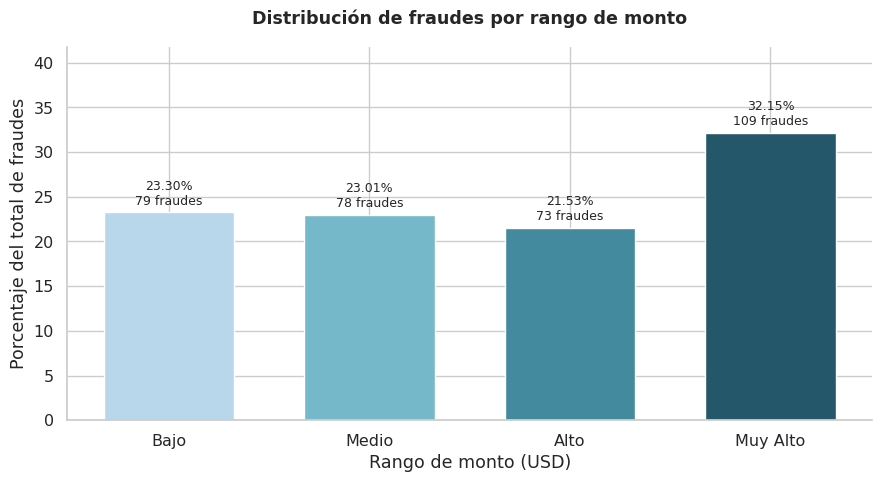

In [517]:
# Orden y nombres de los rangos
nombres_cuartiles = ["Bajo", "Medio", "Alto", "Muy Alto"]

# Crear los rangos usando todas las transacciones
df_fraude["montos_fraude"] = pd.qcut(
    df_fraude["amount_usd"],
    q=4,
    labels=nombres_cuartiles,
    duplicates="drop"
)

# Contar todas las transacciones y los fraudes dentro de cada rango
tabla_monto_fraude = (
    df_fraude.groupby("montos_fraude", observed=False)
    .agg(
        cantidad=("is_fraud", "size"),
        fraudes=("is_fraud", "sum")
    )
    .reindex(nombres_cuartiles)
)

# Calcular la tasa de fraude dentro de cada rango
tabla_monto_fraude["porcentaje_fraude"] = (
    100 * tabla_monto_fraude["fraudes"]
    / tabla_monto_fraude["cantidad"]
)

# Calcular qué porcentaje del total de fraudes corresponde a cada rango
total_fraudes = tabla_monto_fraude["fraudes"].sum()

tabla_monto_fraude["porcentaje_del_total_de_fraudes"] = (
    100 * tabla_monto_fraude["fraudes"] / total_fraudes
)

display(tabla_monto_fraude.round(2))

# Gráfico: distribución del total de fraudes por rango de monto
sns.set_theme(style="whitegrid", font_scale=1.05)

fig, ax = plt.subplots(figsize=(9, 5))
colores = ["#B9D7EA", "#75B8C9", "#438A9E", "#24576A"]

valores = tabla_monto_fraude.loc[
    nombres_cuartiles, "porcentaje_del_total_de_fraudes"
]

barras = ax.bar(
    nombres_cuartiles,
    valores,
    color=colores,
    width=0.65
)

for barra, grupo in zip(barras, nombres_cuartiles):
    porcentaje = tabla_monto_fraude.loc[
        grupo, "porcentaje_del_total_de_fraudes"
    ]
    fraudes = tabla_monto_fraude.loc[grupo, "fraudes"]

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{porcentaje:.2f}%\n{fraudes:.0f} fraudes",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    "Distribución de fraudes por rango de monto",
    pad=16,
    weight="bold"
)
ax.set_xlabel("Rango de monto (USD)")
ax.set_ylabel("Porcentaje del total de fraudes")
ax.set_ylim(0, valores.max() * 1.3)

sns.despine()
plt.tight_layout()
plt.show()

De los 339 fraudes, 109 (32,15 %) ocurrieron en el rango de monto Muy Alto. En los rangos Bajo, Medio y Alto hubo 79 (23,30 %), 78 (23,01 %) y 73 (21,53 %), respectivamente. Así, en esta gráfica, el grupo Muy Alto reúne la mayor parte de los fraudes.

## **4. Variables temporales, relacionar días y horas de la transacción y por indicador de fraude (is_fraude)**

,day_of_week,dia_nombre,time_of_day_hour,transacciones,fraudes,porcentaje_fraude
0,0,Lunes,0,112,3,2.68
1,0,Lunes,1,123,1,0.81
2,0,Lunes,2,112,8,7.14
3,0,Lunes,3,109,3,2.75
4,0,Lunes,4,133,3,2.26
...,...,...,...,...,...,...
163,6,Domingo,19,126,3,2.38
164,6,Domingo,20,126,1,0.79
165,6,Domingo,21,115,0,0.00
166,6,Domingo,22,114,3,2.63


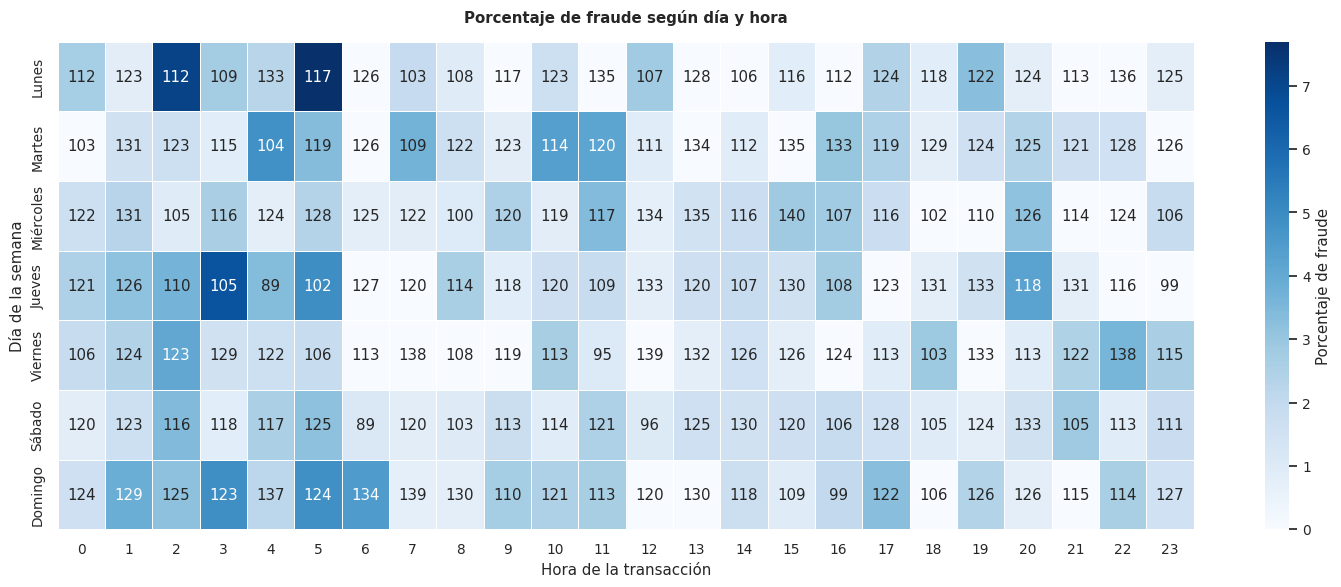

In [518]:
dias_de_la_semana = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

orden_dias = list(dias_de_la_semana.values())

# Crear una copia temporal con los nombres de los días
df_tiempo = df_fraude.assign(
    dia_nombre=df_fraude["day_of_week"].astype(int).map(dias_de_la_semana)
)

# Calcular transacciones y fraudes por día y hora
tabla_tiempo = (
    df_tiempo.groupby(
        ["day_of_week", "dia_nombre", "time_of_day_hour"],
        observed=True
    )
    .agg(
        transacciones=("is_fraud", "size"),
        fraudes=("is_fraud", "sum")
    )
    .reset_index()
)

tabla_tiempo["porcentaje_fraude"] = (
    100 * tabla_tiempo["fraudes"] / tabla_tiempo["transacciones"]
)

display(tabla_tiempo.round(2))

# Preparar matrices para el mapa de calor
tasas = (
    tabla_tiempo.pivot(
        index="dia_nombre",
        columns="time_of_day_hour",
        values="porcentaje_fraude"
    )
    .reindex(orden_dias)
)

cantidades = (
    tabla_tiempo.pivot(
        index="dia_nombre",
        columns="time_of_day_hour",
        values="transacciones"
    )
    .reindex(orden_dias)
)

# Mostrar la cantidad de transacciones en cada cuadro
anotaciones = cantidades.fillna(0).astype(int).astype(str)
anotaciones = anotaciones.mask(cantidades.isna(), "")

# Crear el mapa de calor azul
sns.set_theme(style="white", font_scale=0.9)

plt.figure(figsize=(15, 6))
sns.heatmap(
    tasas,
    cmap="Blues",
    linewidths=0.4,
    linecolor="white",
    annot=anotaciones,
    fmt="",
    cbar_kws={"label": "Porcentaje de fraude"}
)

plt.title("Porcentaje de fraude según día y hora", weight="bold", pad=14)
plt.xlabel("Hora de la transacción")
plt.ylabel("Día de la semana")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

En este conjunto de datos, la proporción de transacciones marcadas como fraude cambia un poco según el día y la hora. Al sumar todas las horas, el domingo tuvo la proporción más alta: 61 de 2.921 transacciones (2,09 %). El viernes tuvo la más baja: 40 de 2.880 (1,39 %). En el mapa también destacan algunas horas, como las 2:00 y las 5:00 del lunes. Esto sugiere que hay ciertas combinaciones de día y hora con más fraude en estos datos, aunque las diferencias son pequeñas y no se repite un mismo patrón durante todos los días.

**Variable 4 - SQL**


In [519]:
query_4 = """
SELECT
    day_of_week,
    CASE day_of_week
        WHEN 0 THEN 'Lunes'
        WHEN 1 THEN 'Martes'
        WHEN 2 THEN 'Miércoles'
        WHEN 3 THEN 'Jueves'
        WHEN 4 THEN 'Viernes'
        WHEN 5 THEN 'Sábado'
        WHEN 6 THEN 'Domingo'
    END AS dia_nombre,
    time_of_day_hour AS hora,
    COUNT(*) AS transacciones,
    SUM(CASE WHEN is_fraud = 1 THEN 1 ELSE 0 END) AS fraudes,
    ROUND(
        100.0 * SUM(CASE WHEN is_fraud = 1 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS porcentaje_fraude
FROM df_fraude
GROUP BY day_of_week, time_of_day_hour
ORDER BY day_of_week, time_of_day_hour;
"""

sql_4 = run_sql(query_4)
display(sql_4)

,day_of_week,dia_nombre,hora,transacciones,fraudes,porcentaje_fraude
0,0,Lunes,0,112,3,2.68
1,0,Lunes,1,123,1,0.81
2,0,Lunes,2,112,8,7.14
3,0,Lunes,3,109,3,2.75
4,0,Lunes,4,133,3,2.26
...,...,...,...,...,...,...
163,6,Domingo,19,126,3,2.38
164,6,Domingo,20,126,1,0.79
165,6,Domingo,21,115,0,0.00
166,6,Domingo,22,114,3,2.63


## **5. Tasa de fraude por canal de transacción**

,fraudes,porcentaje_del_total_de_fraudes
tipo_canal,,
Online,187,55.16
Físico,152,44.84


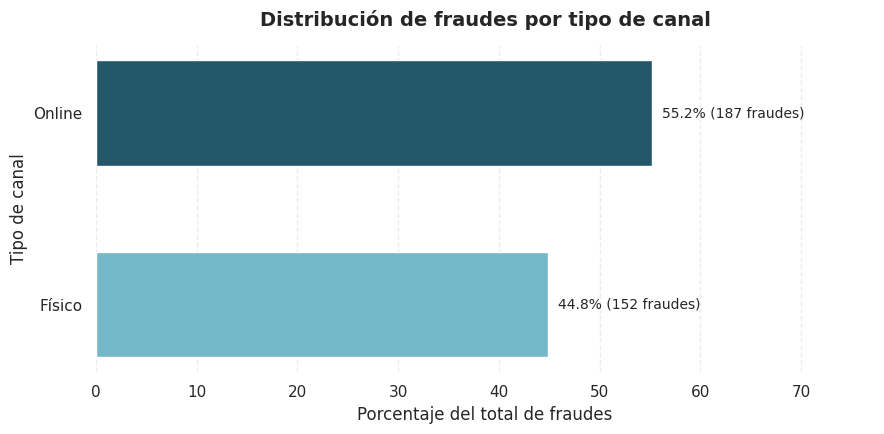

In [520]:


# Conservar únicamente las transacciones fraudulentas
df_solo_fraudes = df_fraude.loc[
    df_fraude["is_fraud"] == True
].copy()

# Agrupar los canales en online y físico
agrupacion_canales = {
    "Online": "Online",
    "In-App": "Online",
    "ATM": "Físico",
    "Contactless": "Físico",
    "POS": "Físico"
}

df_solo_fraudes["tipo_canal"] = (
    df_solo_fraudes["channel"].map(agrupacion_canales)
)

# Comprobar que todos los canales tengan una categoría asignada
canales_sin_agrupar = df_solo_fraudes.loc[
    df_solo_fraudes["tipo_canal"].isna(),
    "channel"
].unique()

if len(canales_sin_agrupar) > 0:
    raise ValueError(f"Hay canales sin agrupar: {canales_sin_agrupar}")

# Contar los fraudes por tipo de canal
tabla_canal_fraudes = (
    df_solo_fraudes
    .groupby("tipo_canal", observed=True)
    .size()
    .to_frame(name="fraudes")
)

# Calcular el porcentaje que representa cada grupo
# del total de transacciones fraudulentas
total_fraudes = tabla_canal_fraudes["fraudes"].sum()

tabla_canal_fraudes["porcentaje_del_total_de_fraudes"] = (
    100 * tabla_canal_fraudes["fraudes"] / total_fraudes
)

# Mostrar primero el grupo con mayor cantidad de fraudes
tabla_canal_fraudes = tabla_canal_fraudes.sort_values(
    "fraudes",
    ascending=False
)

display(tabla_canal_fraudes.round(2))

# Ordenar las barras para que el grupo mayor aparezca arriba
tabla_grafico = tabla_canal_fraudes.sort_values(
    "porcentaje_del_total_de_fraudes",
    ascending=True
)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 4.5))

colores_por_canal = {
    "Físico": "#75B8C9",
    "Online": "#24576A"
}

colores = [
    colores_por_canal[tipo]
    for tipo in tabla_grafico.index
]

barras = ax.barh(
    tabla_grafico.index,
    tabla_grafico["porcentaje_del_total_de_fraudes"],
    color=colores,
    height=0.55
)

# Mostrar el porcentaje y la cantidad de fraudes al final de cada barra
for barra, (_, fila) in zip(barras, tabla_grafico.iterrows()):
    ax.text(
        barra.get_width() + 1,
        barra.get_y() + barra.get_height() / 2,
        f'{fila["porcentaje_del_total_de_fraudes"]:.1f}% '
        f'({int(fila["fraudes"])} fraudes)',
        va="center",
        fontsize=10
    )

ax.set_title(
    "Distribución de fraudes por tipo de canal",
    fontsize=14,
    weight="bold",
    pad=14
)
ax.set_xlabel("Porcentaje del total de fraudes")
ax.set_ylabel("Tipo de canal")
ax.set_xlim(
    0,
    tabla_grafico["porcentaje_del_total_de_fraudes"].max() * 1.4
)
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.grid(axis="y", visible=False)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

De las 339 transacciones fraudulentas, 187 (55,2 %) fueron de canales online —Online e In-App— y 152 (44,8 %) de canales físicos —ATM, Contactless y POS—. En este conjunto hubo más fraudes online, pero la diferencia fue pequeña. Como el análisis incluye solo transacciones fraudulentas, no permite saber si las compras online tenían mayor probabilidad de fraude.

## **6. Porcentaje de fraude por canal y condición extranjera**

/tmp/ipykernel_4936/1881049103.py:12: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_fraudes_canal["channel"].replace({
/tmp/ipykernel_4936/1881049103.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("canal_agrupado")["fraudes"]


,canal_agrupado,tipo_transaccion,fraudes,porcentaje_del_total_de_fraudes,porcentaje_dentro_del_canal
0,ATM,Transacción internacional,3,0.88,12.00
1,ATM,Transacción nacional,22,6.49,88.00
2,Contactless,Transacción internacional,11,3.24,22.92
3,Contactless,Transacción nacional,37,10.91,77.08
4,Otros,Transacción internacional,35,10.32,26.72
5,Otros,Transacción nacional,96,28.32,73.28
6,Online,Transacción internacional,24,7.08,17.78
7,Online,Transacción nacional,111,32.74,82.22


/tmp/ipykernel_4936/1881049103.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("canal_agrupado")["fraudes"]


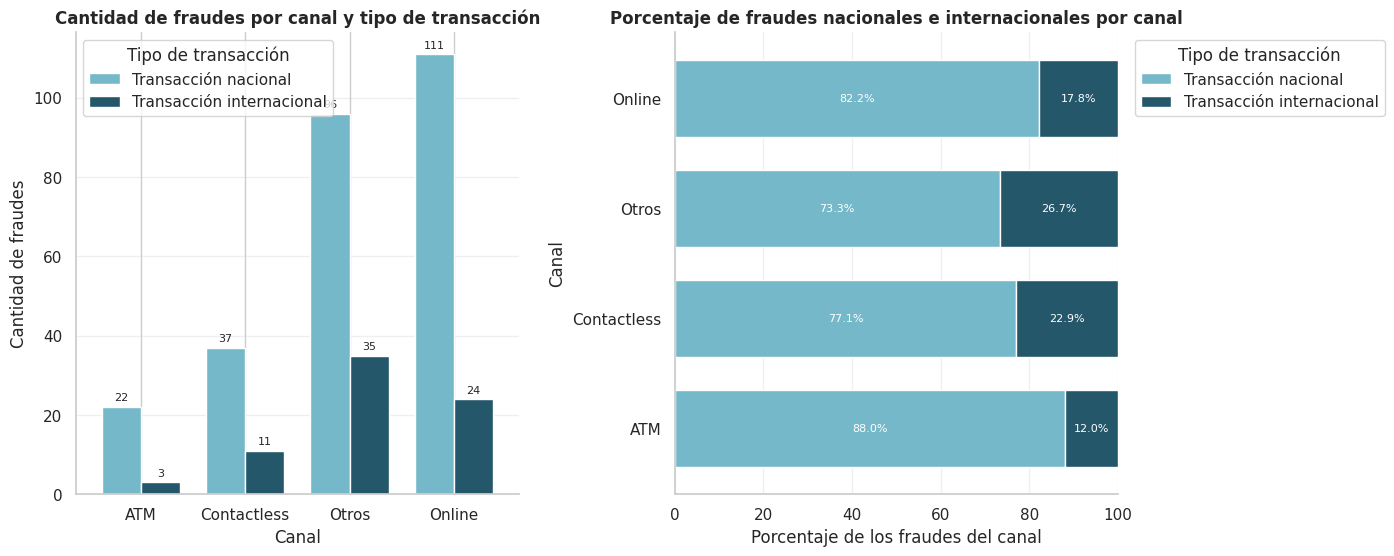

In [521]:
# Crear una copia temporal con solo las transacciones fraudulentas
# df_solo_fraudes debe contener únicamente los fraudes
df_fraudes_canal = df_solo_fraudes.assign(
    tipo_transaccion=df_solo_fraudes["is_foreign_transaction"].map({
        False: "Transacción nacional",
        True: "Transacción internacional"
    })
)

# Agrupar In-App y POS como "Otros"
df_fraudes_canal["canal_agrupado"] = (
    df_fraudes_canal["channel"].replace({
        "In-App": "Otros",
        "POS": "Otros"
    })
)

orden_tipos = [
    "Transacción nacional",
    "Transacción internacional"
]

# Contar fraudes por canal y tipo de transacción
tabla_canal_extranjero = (
    df_fraudes_canal
    .groupby(
        ["canal_agrupado", "tipo_transaccion"],
        observed=True
    )
    .size()
    .reset_index(name="fraudes")
)

total_fraudes = len(df_fraudes_canal)

# Porcentaje de cada grupo respecto al total de fraudes
tabla_canal_extranjero["porcentaje_del_total_de_fraudes"] = (
    100 * tabla_canal_extranjero["fraudes"] / total_fraudes
)

# Porcentaje nacional e internacional dentro de cada canal
total_por_canal = (
    tabla_canal_extranjero
    .groupby("canal_agrupado")["fraudes"]
    .transform("sum")
)

tabla_canal_extranjero["porcentaje_dentro_del_canal"] = (
    100 * tabla_canal_extranjero["fraudes"] / total_por_canal
)

# Mostrar la tabla
display(tabla_canal_extranjero.round(2))

# Ordenar los canales por cantidad total de fraudes.
# Para el gráfico horizontal, el canal con más fraudes quedará arriba.
orden_canales = (
    tabla_canal_extranjero
    .groupby("canal_agrupado")["fraudes"]
    .sum()
    .sort_values(ascending=True)
    .index
)

# Preparar los datos para el gráfico de cantidades
conteos = (
    tabla_canal_extranjero
    .pivot(
        index="canal_agrupado",
        columns="tipo_transaccion",
        values="fraudes"
    )
    .reindex(index=orden_canales, columns=orden_tipos)
    .fillna(0)
)

# Preparar los datos para el gráfico de porcentajes
porcentajes_por_canal = (
    tabla_canal_extranjero
    .pivot(
        index="canal_agrupado",
        columns="tipo_transaccion",
        values="porcentaje_dentro_del_canal"
    )
    .reindex(index=orden_canales, columns=orden_tipos)
    .fillna(0)
)

colores = ["#75B8C9", "#24576A"]
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: cantidad de fraudes por canal y tipo de transacción
conteos.plot(
    kind="bar",
    ax=axes[0],
    color=colores,
    width=0.75
)

axes[0].set_title(
    "Cantidad de fraudes por canal y tipo de transacción",
    weight="bold"
)
axes[0].set_xlabel("Canal")
axes[0].set_ylabel("Cantidad de fraudes")
axes[0].legend(title="Tipo de transacción", loc="upper left")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.3)

for contenedor in axes[0].containers:
    etiquetas = [
        f"{barra.get_height():.0f}" if barra.get_height() > 0 else ""
        for barra in contenedor
    ]
    axes[0].bar_label(
        contenedor,
        labels=etiquetas,
        padding=3,
        fontsize=8
    )

# Gráfico 2: porcentaje nacional e internacional dentro de cada canal
porcentajes_por_canal.plot(
    kind="barh",
    stacked=True,
    ax=axes[1],
    color=colores,
    width=0.7
)

axes[1].set_title(
    "Porcentaje de fraudes nacionales e internacionales por canal",
    weight="bold"
)
axes[1].set_xlabel("Porcentaje de los fraudes del canal")
axes[1].set_ylabel("Canal")
axes[1].set_xlim(0, 100)
axes[1].grid(axis="x", alpha=0.3)

# Ubicar la leyenda fuera del gráfico para que no tape las barras
axes[1].legend(
    title="Tipo de transacción",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

# Etiquetar los porcentajes en las barras
for contenedor in axes[1].containers:
    etiquetas = [
        f"{barra.get_width():.1f}%"
        if barra.get_width() >= 8
        else ""
        for barra in contenedor
    ]
    axes[1].bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8,
        color="white"
    )

sns.despine()

# Reservar espacio para la leyenda externa
fig.subplots_adjust(right=0.82, wspace=0.35)
plt.show()

Entre los fraudes analizados, Online tuvo la mayor cantidad: 135. De esos casos, el 82,2 % fueron nacionales y el 17,8 % internacionales. En Otros —que agrupa In-App y POS— hubo 131 fraudes; el 73,3 % fueron nacionales y el 26,7 % internacionales. ATM tuvo la menor cantidad, con 25 casos. Estos porcentajes describen cómo se distribuyen los fraudes dentro de cada canal; no indican qué canal tiene mayor probabilidad de fraude entre todas sus transacciones.

## **7. Distribución de transacciones fraudulentas por franquicia de tarjeta**

,fraudes,porcentaje_del_total_de_fraudes
card_type,,
Visa,150,44.25
Mastercard,102,30.09
Amex,43,12.68
RuPay,24,7.08
Discover,20,5.90


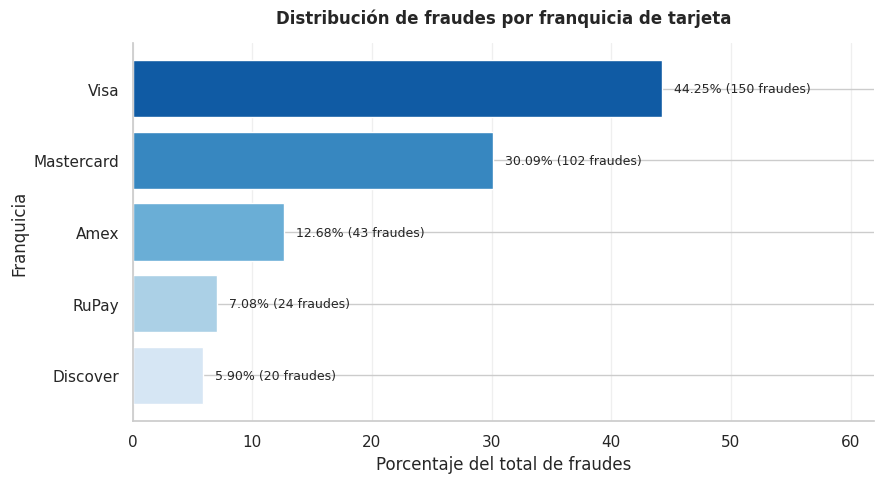

In [522]:


# Conservar únicamente las transacciones marcadas como fraude
df_solo_fraudes = df_fraude.loc[
    df_fraude["is_fraud"] == True
].copy()

# Contar los fraudes por franquicia
tabla_fraudes_franquicia = (
    df_solo_fraudes
    .groupby("card_type", observed=True)
    .size()
    .to_frame(name="fraudes")
)

# Calcular el porcentaje del total de fraudes
# que representa cada franquicia
total_fraudes = tabla_fraudes_franquicia["fraudes"].sum()

tabla_fraudes_franquicia["porcentaje_del_total_de_fraudes"] = (
    100 * tabla_fraudes_franquicia["fraudes"] / total_fraudes
)

# Mostrar primero la franquicia con más fraudes
tabla_fraudes_franquicia = tabla_fraudes_franquicia.sort_values(
    "fraudes",
    ascending=False
)

display(tabla_fraudes_franquicia.round(2))

# Ordenar las barras para que la franquicia con más fraudes
# aparezca arriba
tabla_grafico = tabla_fraudes_franquicia.sort_values(
    "porcentaje_del_total_de_fraudes",
    ascending=True
)

# Crear gráfico horizontal
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 5))

colores = sns.color_palette("Blues", n_colors=len(tabla_grafico))

barras = ax.barh(
    tabla_grafico.index.astype(str),
    tabla_grafico["porcentaje_del_total_de_fraudes"],
    color=colores
)

# Agregar porcentaje y cantidad al final de cada barra
for barra, (_, fila) in zip(barras, tabla_grafico.iterrows()):
    ax.text(
        barra.get_width() + 1,
        barra.get_y() + barra.get_height() / 2,
        f'{fila["porcentaje_del_total_de_fraudes"]:.2f}% '
        f'({int(fila["fraudes"])} fraudes)',
        va="center",
        fontsize=9
    )

ax.set_title(
    "Distribución de fraudes por franquicia de tarjeta",
    weight="bold",
    pad=14
)
ax.set_xlabel("Porcentaje del total de fraudes")
ax.set_ylabel("Franquicia")
ax.set_xlim(
    0,
    tabla_grafico["porcentaje_del_total_de_fraudes"].max() * 1.4
)
ax.grid(axis="x", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

De los 339 fraudes analizados, 150 (44,25 %) fueron con tarjetas Visa y 102 (30,09 %) con Mastercard. Juntas representan cerca de tres de cada cuatro fraudes registrados. Esto indica que Visa y Mastercard aparecen con más frecuencia en los casos de fraude de este conjunto; no significa que sean más propensas al fraude, porque aquí solo se analizaron transacciones fraudulentas.

## **8. Rangos por cuartiles de hours_since_last_txn**

In [523]:
df_fraude["rango_horas"] = pd.qcut(
    df_fraude["hours_since_last_txn"],
    4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

df_fraude[["hours_since_last_txn", "rango_horas"]]

,hours_since_last_txn,rango_horas
0,13.54,Q4
1,0.71,Q1
2,0.35,Q1
3,3.42,Q2
4,2.43,Q1
...,...,...
19995,8.82,Q3
19996,45.81,Q4
19997,20.67,Q4
19998,22.94,Q4


## 9. Relación de los rangos de la última hora y fraude

In [524]:
df_fraude["rango_horas"] = pd.qcut(
    df_fraude["hours_since_last_txn"],
    4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

df_fraude[["hours_since_last_txn", "rango_horas"]]

,hours_since_last_txn,rango_horas
0,13.54,Q4
1,0.71,Q1
2,0.35,Q1
3,3.42,Q2
4,2.43,Q1
...,...,...
19995,8.82,Q3
19996,45.81,Q4
19997,20.67,Q4
19998,22.94,Q4


In [525]:
duckdb.sql("""
SELECT
    hours_since_last_txn,
    NTILE(4) OVER (
        ORDER BY hours_since_last_txn
    ) AS rango_horas
FROM df_fraude
ORDER BY hours_since_last_txn
""")

┌──────────────────────┬─────────────┐
│ hours_since_last_txn │ rango_horas │
│        double        │    int64    │
├──────────────────────┼─────────────┤
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                 0.01 │           1 │
│                   ·  │           · │
│                   ·  │           · │
│                   ·  │           · │
│                  6.2 │           2 │
│                  6.2 │           2 │
│                  6.2 │           2 │
│                  6.2 │           2 │
│                  6.2 │           2 │
│                  6.2 │           2 │
│                 6.21 │           2 │
│                 6.21 │           2 │
│                 6.21 │ 

**9. Variable de relación de los rangos de la última hora y fraude**

In [526]:
#variable de relación de los rangos de la última hora y fraude

resultado = pd.crosstab(
    df_fraude["rango_horas"],
    df_fraude["is_fraud"],
    normalize="index"
)[True] * 100

resultado.round(2)

,True
rango_horas,
Q1,2.51
Q2,1.52
Q3,1.46
Q4,1.28


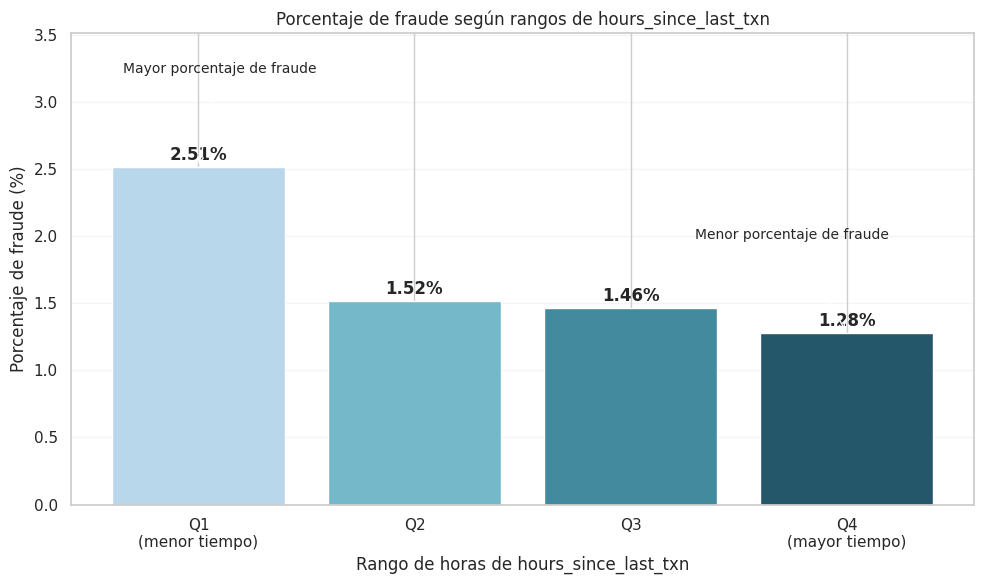

In [527]:
import matplotlib.pyplot as plt

colores = ["#B9D7EA", "#75B8C9", "#438A9E", "#24576A"]

plt.figure(figsize=(10, 6))

barras = plt.bar(
    resultado.index,
    resultado.values,
    color=colores
)

plt.xlabel("Rango de horas de hours_since_last_txn")
plt.ylabel("Porcentaje de fraude (%)")
plt.title("Porcentaje de fraude según rangos de hours_since_last_txn")

for barra, valor in zip(barras, resultado.values):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.05,
        f"{valor:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.annotate(
    "Mayor porcentaje de fraude",
    xy=(0, resultado.iloc[0]),
    xytext=(-0.35, resultado.iloc[0] + 0.7),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.annotate(
    "Menor porcentaje de fraude",
    xy=(3, resultado.iloc[3]),
    xytext=(2.3, resultado.iloc[3] + 0.7),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.xticks(
    range(4),
    ["Q1\n(menor tiempo)", "Q2", "Q3", "Q4\n(mayor tiempo)"]
)

plt.ylim(0, resultado.max() + 1)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.show()

## **10. Variable de transacciones en 24h por fraude**

In [528]:
# Variable de transacciones en 24h por fraude

resultado_24h = df_fraude.groupby(
    "is_fraud"
)["txn_count_last_24h"].agg(
    ["count", "mean", "min", "max"]
).round(2)

resultado_24h

,count,mean,min,max
is_fraud,,,,
False,19661,3.18,0,11
True,339,4.00,0,12


Las transacciones fraudulentas presentan un promedio de 4,00 transacciones en las últimas 24 horas, mientras que las no fraudulentas presentan un promedio de 3,18. Además, el máximo es ligeramente mayor en las transacciones fraudulentas (12 frente a 11). Esto muestra que, en los datos analizados, las transacciones fraudulentas presentan una mayor cantidad promedio de transacciones recientes.

## **11. Variable entre monto, edad del cliente y fraude**

In [529]:
# variable entre monto, edad del cliente y fraude

resultado_corr = df_fraude[
    ["amount_usd", "customer_age", "is_fraud"]
].corr().round(2)

resultado_corr

,amount_usd,customer_age,is_fraud
amount_usd,1.00,-0.01,0.02
customer_age,-0.01,1.00,0.02
is_fraud,0.02,0.02,1.00


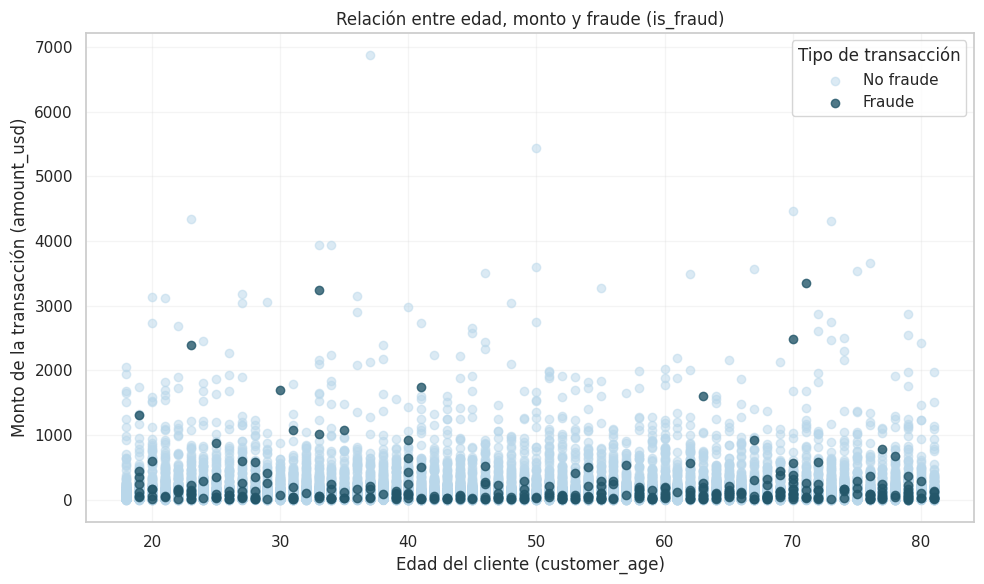

In [530]:
import matplotlib.pyplot as plt

colores = ["#B9D7EA", "#24576A"]

plt.figure(figsize=(10, 6))

plt.scatter(
    df_fraude.loc[df_fraude["is_fraud"] == False, "customer_age"],
    df_fraude.loc[df_fraude["is_fraud"] == False, "amount_usd"],
    color=colores[0],
    alpha=0.5,
    label="No fraude"
)

plt.scatter(
    df_fraude.loc[df_fraude["is_fraud"] == True, "customer_age"],
    df_fraude.loc[df_fraude["is_fraud"] == True, "amount_usd"],
    color=colores[1],
    alpha=0.8,
    label="Fraude"
)

plt.xlabel("Edad del cliente (customer_age)")
plt.ylabel("Monto de la transacción (amount_usd)")
plt.title("Relación entre edad, monto y fraude (is_fraud)")

plt.legend(title="Tipo de transacción")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

No se observa una relación significativa entre el monto de la transacción, la edad del cliente y el fraude. La correlación entre el monto y el fraude es de 0,02, mientras que entre la edad y el fraude también es de 0,02. Además, el gráfico muestra que los casos de fraude están distribuidos entre diferentes edades y montos, sin una concentración clara.

## **12. Porcentaje de fraude según el método de autenticación**

In [531]:
#porcentaje de fraude según el método de autenticación

resultado_auth_canal = pd.crosstab(
    df_fraude["auth_method"],
    df_fraude["channel"],
    values=df_fraude["is_fraud"],
    aggfunc="mean"
) * 100

resultado_auth_canal = resultado_auth_canal.round(2)

resultado_auth_canal

channel,ATM,Contactless,In-App,Online,POS
auth_method,,,,,
3D Secure,2.35,0.88,2.32,1.43,1.44
Biometric,1.06,0.37,0.39,1.39,0.39
No Authentication,2.94,4.27,2.95,6.00,3.96
OTP,1.13,1.48,0.91,1.92,1.69
PIN,1.79,1.12,1.57,1.04,0.90


In [532]:
tabla_auth_canal = pd.crosstab(
    df_fraude["auth_method"],
    df_fraude["channel"],
    values=df_fraude["is_fraud"],
    aggfunc="mean"
) * 100

tabla_auth_canal = tabla_auth_canal.round(2)

tabla_auth_canal.style.format(
    "{:.2f}%"
).background_gradient(
    cmap="Blues"
).set_caption(
    "Porcentaje de fraude según método de autenticación y canal"
)

channel,ATM,Contactless,In-App,Online,POS
auth_method,,,,,
3D Secure,2.35%,0.88%,2.32%,1.43%,1.44%
Biometric,1.06%,0.37%,0.39%,1.39%,0.39%
No Authentication,2.94%,4.27%,2.95%,6.00%,3.96%
OTP,1.13%,1.48%,0.91%,1.92%,1.69%
PIN,1.79%,1.12%,1.57%,1.04%,0.90%


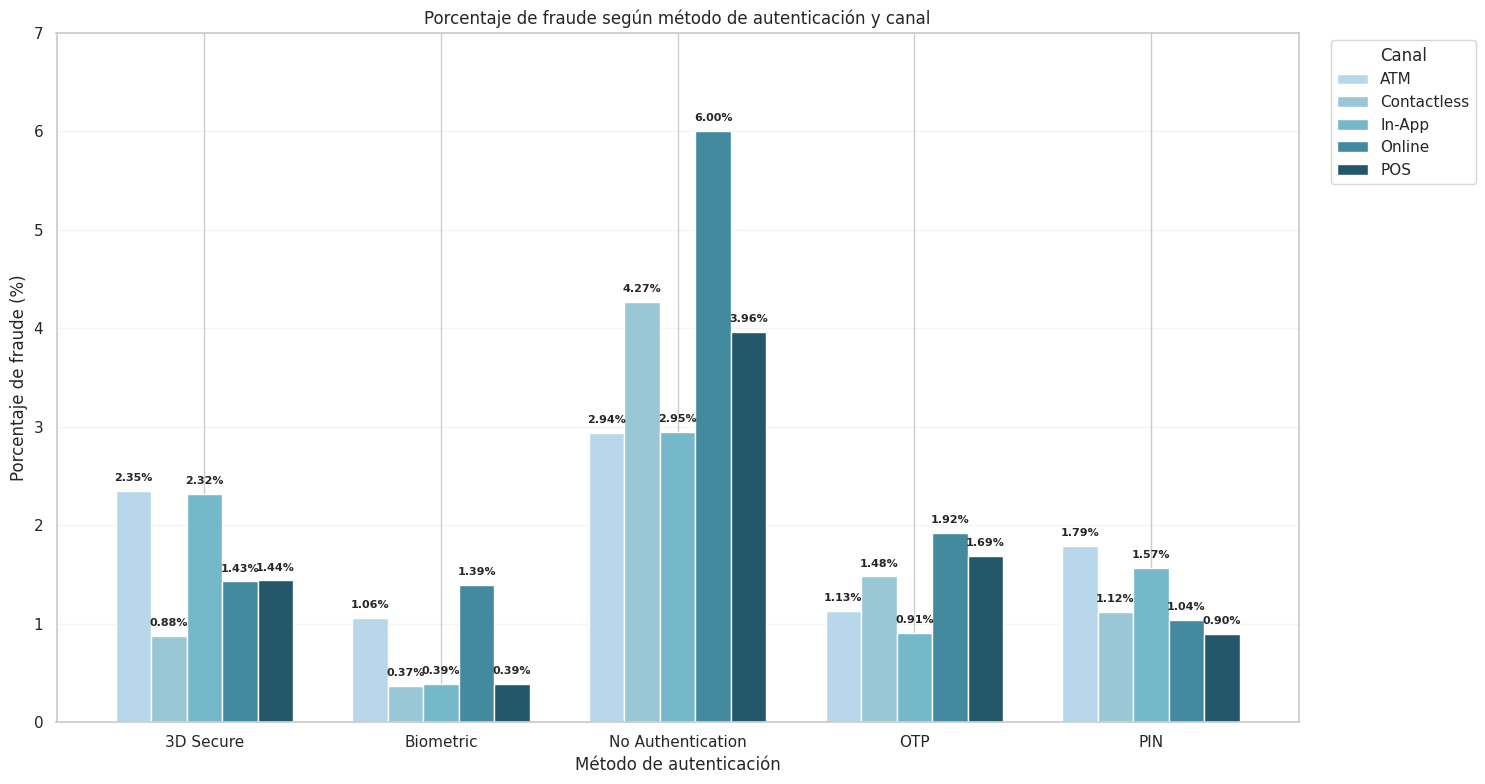

In [533]:
resultado_auth_canal = pd.crosstab(
    df_fraude["auth_method"],
    df_fraude["channel"],
    values=df_fraude["is_fraud"],
    aggfunc="mean"
) * 100

resultado_auth_canal = resultado_auth_canal.round(2)

colores = [
    "#B9D7EA",
    "#9AC7D5",
    "#75B8C9",
    "#438A9E",
    "#24576A"
]

ax = resultado_auth_canal.plot(
    kind="bar",
    figsize=(15, 8),
    color=colores,
    width=0.75
)

plt.xlabel("Método de autenticación")
plt.ylabel("Porcentaje de fraude (%)")
plt.title("Porcentaje de fraude según método de autenticación y canal")
plt.xticks(rotation=0)

plt.legend(
    title="Canal",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.2)

for contenedor in ax.containers:
    for barra in contenedor:
        valor = barra.get_height()

        if valor > 0:
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                valor + 0.08,
                f"{valor:.2f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold"
            )

plt.ylim(0, 7)

plt.tight_layout()
plt.show()

El porcentaje de fraude varía según el método de autenticación. “No Authentication” presenta el mayor porcentaje de fraude, con 4,44 %, mientras que “Biometric” presenta el menor, con 0,78 %. Los demás métodos se encuentran entre estos valores, mostrando diferencias en el porcentaje de fraude según el método utilizado.

## **13. Variable de categoria de mercado, fraude y monto (SQL)**

In [534]:
#Variable de categoria de mercado, fraude y monto (SQL)


resultado_mercado = df_fraude.groupby(
    ["merchant_category", "is_fraud"]
)["amount_usd"].mean().reset_index().round(2)

resultado_mercado

/tmp/ipykernel_4936/3272830355.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resultado_mercado = df_fraude.groupby(


,merchant_category,is_fraud,amount_usd
0,Crypto Exchange,False,349.32
1,Crypto Exchange,True,506.59
2,Electronics,False,302.67
3,Electronics,True,279.18
4,Fuel,False,53.59
5,Fuel,True,65.51
6,Gaming,False,80.09
7,Gaming,True,172.47
8,Gift Cards,False,88.09
9,Gift Cards,True,111.20


In [535]:
duckdb.sql("""
SELECT
    merchant_category,
    is_fraud,
    ROUND(AVG(amount_usd), 2) AS monto_promedio
FROM df_fraude
GROUP BY merchant_category, is_fraud
ORDER BY merchant_category, is_fraud
""")

┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬──────────┬────────────────┐
│                                                                           merchant_category                                                                           │ is_fraud │ monto_promedio │
│ enum('crypto exchange', 'electronics', 'fuel', 'gaming', 'gift cards', 'groceries', 'healthcare', 'online retail', 'restaurants', 'streaming', 'travel', 'utilities') │ boolean  │     double     │
├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼──────────┼────────────────┤
│ Crypto Exchange                                                                                                                                                       │ false    │         349.32 │
│ Crypto E

El monto promedio de las transacciones fraudulentas varía según la categoría de mercado. En la mayoría de las categorías, las transacciones fraudulentas presentan un monto promedio mayor que las no fraudulentas, especialmente en Travel, Crypto Exchange y Gaming. Sin embargo, existen excepciones como Electronics y Healthcare, donde el monto promedio de las transacciones fraudulentas es menor.

## **14. Variable de categoría de mercado, fraude y día de la semana**

In [536]:
# Número real de transacciones fraudulentas por categoría y día

dias = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

df_fraude["dia"] = df_fraude["day_of_week"].map(dias)

tabla_dia = pd.crosstab(
    df_fraude["merchant_category"],
    df_fraude["dia"],
    values=df_fraude["is_fraud"],
    aggfunc="mean"
) * 100

tabla_dia.round(2)

dia,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
merchant_category,,,,,,,
Crypto Exchange,5.68,3.53,5.32,4.55,8.45,4.44,2.99
Electronics,2.16,1.52,3.53,1.87,2.98,2.49,2.06
Fuel,2.69,0.91,1.36,0.89,0.00,1.89,0.82
Gaming,3.12,5.41,1.94,3.52,1.45,3.62,6.45
Gift Cards,7.23,5.75,3.37,9.30,1.28,2.70,1.67
Groceries,0.67,0.91,1.50,0.88,1.05,1.04,2.51
Healthcare,1.08,1.74,1.15,1.18,1.08,1.61,1.23
Online Retail,0.43,0.98,0.41,1.02,1.17,0.85,1.67
Restaurants,1.06,1.06,0.57,1.37,1.10,1.48,1.40


In [537]:

# número real de fraudes

tabla_fraudes = pd.crosstab(
    df_fraude["merchant_category"],
    df_fraude["dia"],
    values=df_fraude["is_fraud"],
    aggfunc="sum"
).fillna(0).astype(int)

tabla_fraudes

dia,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
merchant_category,,,,,,,
Crypto Exchange,5,3,5,3,6,4,2
Electronics,6,5,10,5,9,7,6
Fuel,6,2,3,2,0,4,2
Gaming,5,8,3,5,2,5,10
Gift Cards,6,5,3,8,1,2,2
Groceries,3,4,7,4,5,5,12
Healthcare,2,3,2,2,2,3,2
Online Retail,2,5,2,5,6,4,8
Restaurants,4,4,2,5,4,5,5


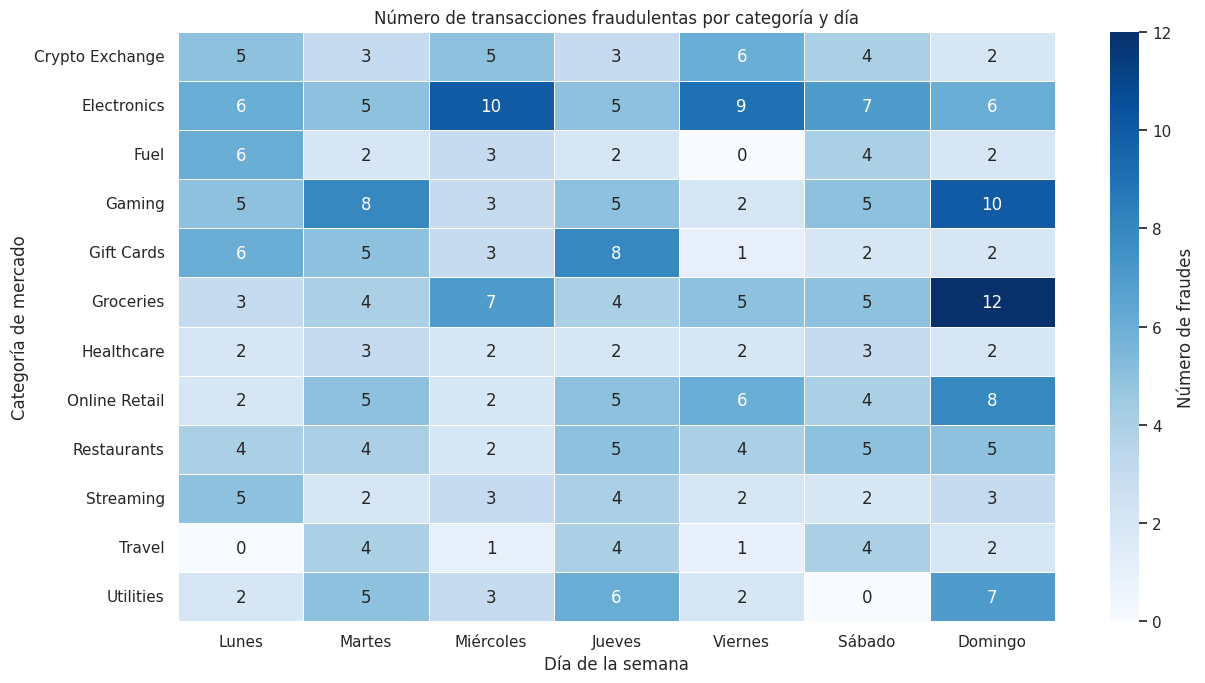

In [538]:
#Graáfica, la de número real de fraudes

plt.figure(figsize=(13, 7))

sns.heatmap(
    tabla_fraudes,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Número de fraudes"}
)

plt.xlabel("Día de la semana")
plt.ylabel("Categoría de mercado")
plt.title("Número de transacciones fraudulentas por categoría y día")

plt.tight_layout()
plt.show()

La combinación de categoría de mercado y día de la semana muestra comportamientos diferentes según se analice la tasa o el número absoluto de fraudes. Gift Cards los jueves presenta la tasa más alta, con 9,30 %, pero corresponde a 8 casos fraudulentos. En cambio, Groceries los domingos concentra el mayor número de fraudes, con 12 casos, aunque su tasa es de 2,51 %. También se observan valores relevantes en Electronics los miércoles y Gaming los domingos, con 10 casos cada uno.


## **15. Antiguedad de la tarjeta vs fraude vs monto**




In [539]:
#Distribución de la variable de Antiguedad
df_fraude['card_age_months'].describe()

,card_age_months
count,20000.000000
mean,46.937550
std,6.768577
min,22.000000
25%,42.000000
50%,47.000000
75%,51.000000
max,74.000000


In [540]:
#Comparación de la distribución Antiguaedad vs Fraude
df_fraude.groupby('is_fraud')['card_age_months'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
False,19661.0,46.948273,6.772515,22.0,42.0,47.0,51.0,74.0
True,339.0,46.315634,6.515622,26.0,41.0,46.0,51.0,68.0


Descriptivamente, las transacciones fraudulentas presentan una antigüedad de tarjeta ligeramente menor que las transacciones no fraudulentas; sin embargo, las distribuciones son muy similares, por lo que esta diferencia por sí sola no evidencia una asociación fuerte entre antigüedad y fraude.

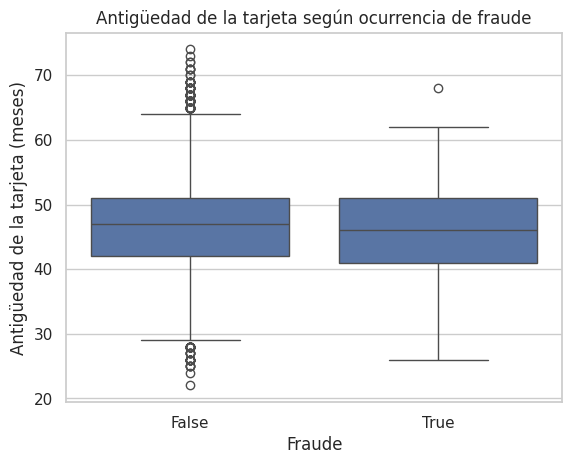

In [541]:
sns.boxplot(
    data=df_fraude,
    x='is_fraud',
    y='card_age_months'
)

plt.xlabel('Fraude')
plt.ylabel('Antigüedad de la tarjeta (meses)')
plt.title('Antigüedad de la tarjeta según ocurrencia de fraude')
plt.show()

Las antigüedades de las tarjetas fraudulentas y no fraudulentas son muy similares y se encuentran dentro de rangos ampliamente compartidos.

In [542]:
#Crear la variable de rangos de Antiguedad por Cuartiles
df_fraude['card_age_quartile'] = pd.qcut(
    df_fraude['card_age_months'],
    q=4,
    labels=['Q1 - Menor antigüedad',
            'Q2 - Antigüedad baja-media',
            'Q3 - Antigüedad media-alta',
            'Q4 - Mayor antigüedad']
)

In [543]:
#Identificar la tasa de fraude para cada grupo de Antiguedad
tabla_antiguedad = pd.crosstab(
    df_fraude['card_age_quartile'],
    df_fraude['is_fraud']
)

tabla_antiguedad['Tasa_fraude_%'] = (
    tabla_antiguedad[True] /
    tabla_antiguedad.sum(axis=1) * 100
).round(1)

tabla_antiguedad

is_fraud,False,True,Tasa_fraude_%
card_age_quartile,,,
Q1 - Menor antigüedad,5128,104,2.0
Q2 - Antigüedad baja-media,5488,90,1.6
Q3 - Antigüedad media-alta,4166,62,1.5
Q4 - Mayor antigüedad,4879,83,1.7


En este conjunto de datos, las transacciones correspondientes al cuartil de menor antigüedad presentan la mayor tasa de fraude observada (2,0 %), mientras que el cuartil de antigüedad media-alta presenta la menor (1,5 %). Esto sugiere una posible asociación entre la antigüedad de la tarjeta y la ocurrencia de fraude, aunque las diferencias observadas son relativamente pequeñas y no permiten establecer causalidad.

In [544]:
#Incluir la Variable de Monto
df_fraude['amount_usd'].describe().round(2)

,amount_usd
count,20000.00
mean,132.42
std,256.96
min,1.00
25%,26.24
50%,57.51
75%,131.75
max,6872.69


In [545]:
#Comparar la variable de monto vs fraude
df_fraude.groupby('is_fraud')['amount_usd'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
False,19661.0,131.58,254.24,1.00,26.21,57.35,130.88,6872.69
True,339.0,181.25,380.46,4.09,28.62,69.77,165.32,3356.46


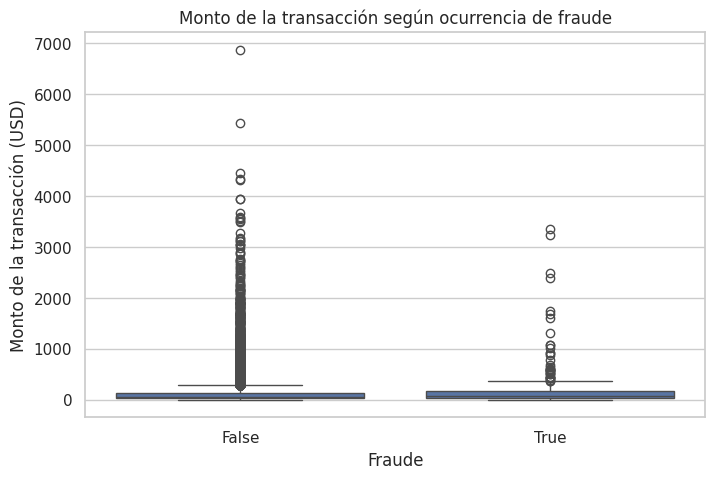

In [546]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_fraude,
    x='is_fraud',
    y='amount_usd'
)

plt.xlabel('Fraude')
plt.ylabel('Monto de la transacción (USD)')
plt.title('Monto de la transacción según ocurrencia de fraude')
plt.show()

In [547]:
#Distribución de las 3 variables juntas
tabla_monto_antiguedad = pd.pivot_table(
    df_fraude,
    values='amount_usd',
    index='card_age_quartile',
    columns='is_fraud',
    aggfunc='median'
)

tabla_monto_antiguedad

/tmp/ipykernel_4936/317765867.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabla_monto_antiguedad = pd.pivot_table(


is_fraud,False,True
card_age_quartile,,
Q1 - Menor antigüedad,55.865,62.765
Q2 - Antigüedad baja-media,55.940,65.540
Q3 - Antigüedad media-alta,57.810,82.300
Q4 - Mayor antigüedad,60.730,58.710


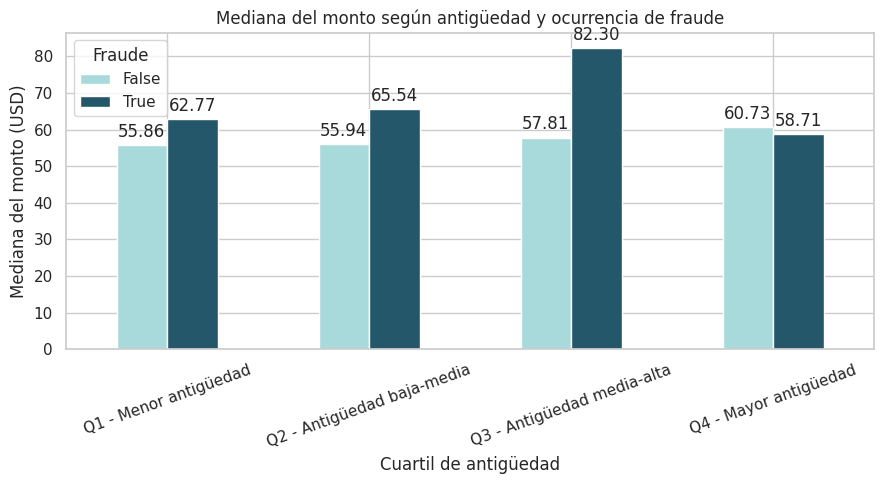

In [548]:
ax = tabla_monto_antiguedad.plot(
    kind='bar',
    figsize=(9, 5),
    color=['#A8DADC', '#24576A']  # azul claro, rosado pastel
)

plt.xlabel('Cuartil de antigüedad')
plt.ylabel('Mediana del monto (USD)')
plt.title('Mediana del monto según antigüedad y ocurrencia de fraude')
plt.xticks(rotation=20)
plt.legend(title='Fraude')

# Etiquetas de valor sobre cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()

Se identifican dos patrones diferentes. Las tarjetas de menor antigüedad tienen la mayor tasa de fraude, con un 2%, pero no son las que presentan los mayores montos fraudulentos. El mayor monto mediano de fraude aparece en Q3, con 82,30 dólares. Por eso, la antigüedad parece relacionarse de manera diferente con la frecuencia del fraude y con el valor de las transacciones.

## **16. Tipo de dispositivo vs fraude vs categoria de mercado**

In [549]:
df_fraude['device_type'].value_counts()

,count
device_type,
Android Phone,5503
iPhone,4179
POS Terminal,3162
Windows PC,2623
Mac,1359
Tablet,1161
Smart Watch,1008
ATM Machine,1005


In [550]:
df_fraude['merchant_category'].value_counts()

,count
merchant_category,
Online Retail,3416
Groceries,3242
Restaurants,2534
Electronics,2032
Fuel,1565
Travel,1420
Utilities,1330
Healthcare,1237
Gaming,1036


In [551]:
import numpy as np

top_4_devices = ['Android Phone', 'iPhone', 'POS Terminal', 'Windows PC']
top_4_markets = ['Online Retail', 'Groceries', 'Restaurants', 'Electronics']

df_fraude['device_group'] = np.where(
    df_fraude['device_type'].isin(top_4_devices),
    df_fraude['device_type'],
    'Otros'
)

df_fraude['market_group'] = np.where(
    df_fraude['merchant_category'].isin(top_4_markets),
    df_fraude['merchant_category'],
    'Otros'
)

In [552]:
df_fraude['device_group'].value_counts()

,count
device_group,
Android Phone,5503
Otros,4533
iPhone,4179
POS Terminal,3162
Windows PC,2623


In [553]:
df_fraude['market_group'].value_counts()

,count
market_group,
Otros,8776
Online Retail,3416
Groceries,3242
Restaurants,2534
Electronics,2032


In [554]:
#Obtener Fraude y tasa de fraude
tabla_device_market = pd.crosstab(
    [df_fraude['device_group'], df_fraude['market_group']],
    df_fraude['is_fraud']
)

tabla_device_market['Tasa_fraude_%'] = (
    tabla_device_market[True] /
    tabla_device_market.sum(axis=1) * 100
).round(2)

tabla_device_market

is_fraud                     False  True  Tasa_fraude_%
device_group  market_group                             
Android Phone Electronics      526    15           2.77
              Groceries        885     7           0.78
              Online Retail    922    11           1.18
              Otros           2339    64           2.66
              Restaurants      727     7           0.95
Otros         Electronics      452    10           2.16
              Groceries        746    15           1.97
              Online Retail    755    10           1.31
              Otros           1962    36           1.80
              Restaurants      535    12           2.19
POS Terminal  Electronics      322     9           2.72
              Groceries        479     8           1.64
              Online Retail    564     3           0.53
              Otros           1366    30           2.15
              Restaurants      377     4           1.05
Windows PC    Electronics      265     3           1.12
              Groceries        421     3           0.71
              Online Retail    427     4           0.93
              Otros           1156    17           1.45
              Restaurants      325     2           0.61
iPhone        Electronics      419    11           2.56
              Groceries        671     7           1.03
              Online Retail    716     4           0.56
              Otros           1763    43           2.38
              Restaurants      541     4           0.73

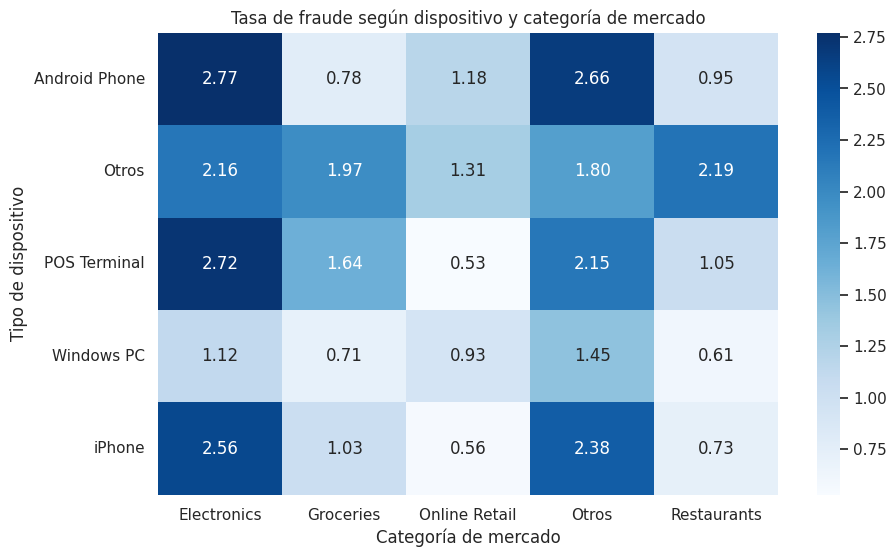

In [555]:
#Visualizar la tasa de fraude
tabla_tasa = tabla_device_market['Tasa_fraude_%'].unstack()

plt.figure(figsize=(10, 6))

sns.heatmap(
    tabla_tasa,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.xlabel('Categoría de mercado')
plt.ylabel('Tipo de dispositivo')
plt.title('Tasa de fraude según dispositivo y categoría de mercado')
plt.show()

La tasa de fraude presenta diferencias según la combinación entre tipo de dispositivo y categoría de mercado. Las tasas más elevadas se observan principalmente en Electronics para Android, POS Terminal e iPhone, mientras que Online Retail presenta tasas relativamente bajas en varios dispositivos. Esto sugiere que la combinación entre dispositivo y categoría de mercado puede aportar información relevante para la identificación de transacciones potencialmente fraudulentas.

## **17. Mercado por primera vez vs categoria de mercado vs fraude**

In [556]:

# Agrupación inicial por afinidad de negocio

grupos_mercado = {
    "Comercio digital": [
        "Online Retail", "Electronics", "Gift Cards"
    ],
    "Entretenimiento digital": [
        "Gaming", "Streaming"
    ],
    "Servicios financieros y digitales": [
        "Crypto Exchange", "Utilities"
    ],
    "Consumo cotidiano": [
        "Groceries", "Restaurants", "Fuel"
    ],
    "Servicios especializados": [
        "Healthcare", "Travel"
    ]
}

mapa_mercado = {
    categoria: grupo
    for grupo, categorias in grupos_mercado.items()
    for categoria in categorias
}

df_fraude["grupo_mercado"] = (
    df_fraude["merchant_category"]
    .map(mapa_mercado)
)

# Verificar que todas las categorías hayan sido agrupadas
print("Categorías sin agrupar:")
display(
    df_fraude.loc[
        df_fraude["grupo_mercado"].isna(),
        "merchant_category"
    ].value_counts()
)

print("Distribución por grupo:")
display(
    df_fraude["grupo_mercado"].value_counts(dropna=False)
)

Categorías sin agrupar:


,count
merchant_category,
Crypto Exchange,0
Electronics,0
Fuel,0
Gaming,0
Gift Cards,0
Groceries,0
Healthcare,0
Online Retail,0
Restaurants,0


Distribución por grupo:


,count
grupo_mercado,
Consumo cotidiano,7341
Comercio digital,6065
Servicios especializados,2657
Entretenimiento digital,2046
Servicios financieros y digitales,1891


In [557]:

# Resumen por grupo de mercado y condición de comercio nuevo

resumen = (
    df_fraude
    .groupby(
        ["grupo_mercado", "is_new_merchant"],
        observed=True,
        dropna=False
    )
    .agg(
        transacciones=("is_fraud", "size"),
        fraudes=("is_fraud", "sum"),
        tasa_fraude=("is_fraud", "mean")
    )
    .reset_index()
)

resumen["tasa_fraude_pct"] = (
    resumen["tasa_fraude"] * 100
).round(2)

total_fraudes = df_fraude["is_fraud"].sum()

resumen["participacion_fraudes_pct"] = (
    resumen["fraudes"] / total_fraudes * 100
).round(2)

display(
    resumen.sort_values(
        ["grupo_mercado", "is_new_merchant"]
    )
)

,grupo_mercado,is_new_merchant,transacciones,fraudes,tasa_fraude,tasa_fraude_pct,participacion_fraudes_pct
0,Comercio digital,False,4649,52,0.011185,1.12,15.34
1,Comercio digital,True,1416,55,0.038842,3.88,16.22
2,Consumo cotidiano,False,5635,49,0.008696,0.87,14.45
3,Consumo cotidiano,True,1706,39,0.022860,2.29,11.50
4,Entretenimiento digital,False,1582,31,0.019595,1.96,9.14
5,Entretenimiento digital,True,464,28,0.060345,6.03,8.26
6,Servicios especializados,False,2039,15,0.007357,0.74,4.42
7,Servicios especializados,True,618,17,0.027508,2.75,5.01
8,Servicios financieros y digitales,False,1494,31,0.020750,2.07,9.14
9,Servicios financieros y digitales,True,397,22,0.055416,5.54,6.49


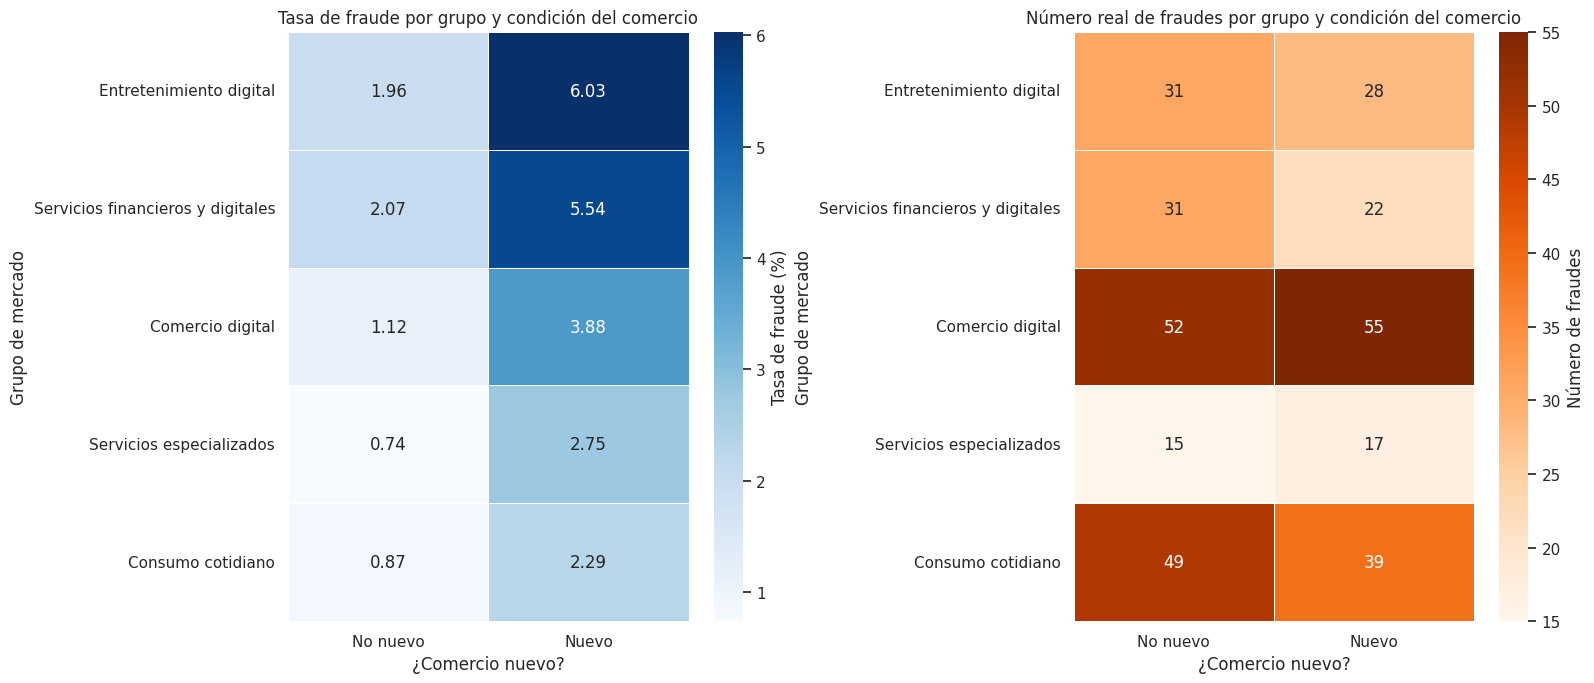

In [558]:
# Tablas de tasas y valores absolutos
tabla_tasas = resumen.pivot(
    index="grupo_mercado",
    columns="is_new_merchant",
    values="tasa_fraude_pct"
).reindex(columns=[False, True])

tabla_fraudes = resumen.pivot(
    index="grupo_mercado",
    columns="is_new_merchant",
    values="fraudes"
).reindex(columns=[False, True])

# Etiquetas para las columnas
nombres_columnas = ["No nuevo", "Nuevo"]

tabla_tasas.columns = nombres_columnas
tabla_fraudes.columns = nombres_columnas

# Ordenar grupos de mayor a menor tasa en comercios nuevos
orden = tabla_tasas["Nuevo"].sort_values(
    ascending=False,
    na_position="last"
).index

tabla_tasas = tabla_tasas.loc[orden]
tabla_fraudes = tabla_fraudes.loc[orden]

# Crear una imagen con dos gráficas
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(
    tabla_tasas,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    mask=tabla_tasas.isna(),
    ax=axes[0],
    cbar_kws={"label": "Tasa de fraude (%)"}
)

axes[0].set_title(
    "Tasa de fraude por grupo y condición del comercio"
)
axes[0].set_xlabel("¿Comercio nuevo?")
axes[0].set_ylabel("Grupo de mercado")

sns.heatmap(
    tabla_fraudes,
    annot=True,
    fmt=".0f",
    cmap="Oranges",
    linewidths=0.5,
    mask=tabla_fraudes.isna(),
    ax=axes[1],
    cbar_kws={"label": "Número de fraudes"}
)

axes[1].set_title(
    "Número real de fraudes por grupo y condición del comercio"
)
axes[1].set_xlabel("¿Comercio nuevo?")
axes[1].set_ylabel("Grupo de mercado")

plt.tight_layout()
plt.show()

In [559]:
#Código en SQL

# 1. Crear una conexión temporal
conexion = sqlite3.connect(":memory:")

# 2. Guardar el DataFrame en SQLite
df_fraude.to_sql(
    "datos_mercado",
    conexion,
    index=False,
    if_exists="replace"
)

# 3. Consultar los datos agrupados
consulta = """
SELECT
    grupo_mercado,
    is_new_merchant,
    COUNT(*) AS total_transacciones,
    SUM(
        CASE
            WHEN is_fraud = 1 THEN 1
            ELSE 0
        END
    ) AS numero_fraudes,
    ROUND(
        100.0 * SUM(
            CASE
                WHEN is_fraud = 1 THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS tasa_fraude_pct
FROM datos_mercado
GROUP BY grupo_mercado, is_new_merchant
ORDER BY grupo_mercado, is_new_merchant;
"""

resumen_sql = pd.read_sql_query(consulta, conexion)

# 4. Mostrar el resultado
display(resumen_sql)

# 5. Cerrar la conexión al terminar
conexion.close()

,grupo_mercado,is_new_merchant,total_transacciones,numero_fraudes,tasa_fraude_pct
0,Comercio digital,0,4649,52,1.12
1,Comercio digital,1,1416,55,3.88
2,Consumo cotidiano,0,5635,49,0.87
3,Consumo cotidiano,1,1706,39,2.29
4,Entretenimiento digital,0,1582,31,1.96
5,Entretenimiento digital,1,464,28,6.03
6,Servicios especializados,0,2039,15,0.74
7,Servicios especializados,1,618,17,2.75
8,Servicios financieros y digitales,0,1494,31,2.07
9,Servicios financieros y digitales,1,397,22,5.54


En los servicios financieros y digitales, los comercios nuevos registran 22 fraudes en 397 transacciones (5,54 %), frente a 31 fraudes en 1.494 transacciones de comercios no nuevos (2,07 %). Aunque presentan menos casos absolutos, su tasa de fraude es 2,67 veces mayor. Esta diferencia también se observa en el conjunto de la base, donde la tasa alcanza el 3,50 % en comercios nuevos y el 1,16 % en no nuevos. Los resultados muestran una asociación descriptiva que debe validarse estadísticamente antes de concluir que la condición de comercio nuevo implica un mayor riesgo.

## **18. Apoyo de IA vs fraude**

In [560]:
# Filtrar únicamente las transacciones fraudulentas
df_solo_fraudes = df_fraude[df_fraude["is_fraud"] == True]

# Contar fraudes según uso de IA
tabla_fraudes_ia = (
    df_solo_fraudes["is_ai_generated_scam_attempt"]
    .value_counts()
    .reindex([False, True], fill_value=0)
    .rename(index={
        False: "Sin apoyo de IA",
        True: "Con apoyo de IA"
    })
    .to_frame(name="Cantidad de fraudes")
)

# Calcular participación sobre el total de fraudes
total_fraudes = tabla_fraudes_ia["Cantidad de fraudes"].sum()

tabla_fraudes_ia["Participación (%)"] = (
    tabla_fraudes_ia["Cantidad de fraudes"] / total_fraudes * 100
).round(2)

display(tabla_fraudes_ia)
print(f"Total de fraudes analizados: {total_fraudes}")

,Cantidad de fraudes,Participación (%)
is_ai_generated_scam_attempt,,
Sin apoyo de IA,305,89.97
Con apoyo de IA,34,10.03


Total de fraudes analizados: 339


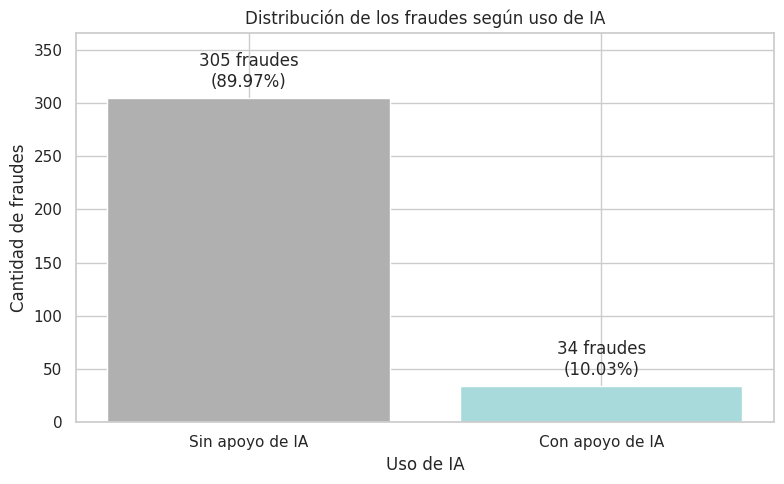

In [561]:

# Datos para graficar
cantidades = tabla_fraudes_ia["Cantidad de fraudes"]
porcentajes = tabla_fraudes_ia["Participación (%)"]

fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(
    cantidades.index,
    cantidades.values,
    color=["#B0B0B0", "#A8DADC"]
)

ax.set_xlabel("Uso de IA")
ax.set_ylabel("Cantidad de fraudes")
ax.set_title("Distribución de los fraudes según uso de IA")

# Mostrar cantidad y participación de cada grupo
for barra, cantidad, porcentaje in zip(
    barras, cantidades.values, porcentajes.values
):
    ax.annotate(
        f"{cantidad} fraudes\n({porcentaje:.2f}%)",
        xy=(barra.get_x() + barra.get_width() / 2, barra.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

ax.set_ylim(0, max(cantidades.values) * 1.2)
plt.tight_layout()
plt.show()

El 89,97 % de los fraudes (305 de 339 casos) se presentó en transacciones sin apoyo de IA, mientras que el 10,03 % (34 casos) estuvo asociado a transacciones con apoyo de IA. Esto indica que, en términos absolutos, la mayoría de los fraudes ocurrió sin apoyo de IA. Sin embargo, esta distribución no significa que el uso de IA represente un menor riesgo: al considerar el total de transacciones de cada grupo, la tasa de fraude fue del 9,07 % en las transacciones con apoyo de IA, frente al 1,55 % en aquellas sin dicho apoyo. Por tanto, aunque los casos con apoyo de IA representan una proporción menor del total de fraudes, presentan una tasa de fraude observada más alta, lo que justifica profundizar en esta relación sin asumir causalidad.

## **19. Saldo de la cuenta usd vs fraude**

El saldo de la cuenta presenta una asociación leve con la ocurrencia de fraude. Las cuentas ubicadas en el cuartil de saldo alto presentan la mayor tasa de fraude (1,84%), mientras que las de saldo bajo presentan la menor (1,48%). Sin embargo, las diferencias entre los rangos son reducidas, por lo que el saldo por sí solo no muestra una separación marcada entre transacciones fraudulentas y no fraudulentas.

In [562]:
#Resumen de las variables agrupadas
df_fraude.groupby('is_fraud')['account_balance_usd'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
False,19661.0,3314.17,4356.88,52.05,1017.48,2005.95,3941.03,127125.86
True,339.0,3461.50,3980.14,86.98,1090.30,2115.47,4215.84,30003.30


In [563]:
#Crear grupos de Saldos por cuartiles y calculo de la Tasa de fraude según rango de saldo
df_fraude['balance_quartile'] = pd.qcut(
    df_fraude['account_balance_usd'],
    q=4,
    labels=['Q1 - Saldo bajo',
            'Q2 - Saldo bajo-medio',
            'Q3 - Saldo medio-alto',
            'Q4 - Saldo alto']
)

tabla_balance_fraude = pd.crosstab(
    df_fraude['balance_quartile'],
    df_fraude['is_fraud']
)

tabla_balance_fraude['Tasa_fraude_%'] = (
    tabla_balance_fraude[True] /
    tabla_balance_fraude.sum(axis=1) * 100
).round(2)

tabla_balance_fraude

is_fraud,False,True,Tasa_fraude_%
balance_quartile,,,
Q1 - Saldo bajo,4926,74,1.48
Q2 - Saldo bajo-medio,4911,89,1.78
Q3 - Saldo medio-alto,4916,84,1.68
Q4 - Saldo alto,4908,92,1.84


In [564]:
#Código en SQL

query_1 = """
WITH datos AS (
    SELECT
        is_fraud,
        NTILE(4) OVER (
            ORDER BY account_balance_usd
        ) AS cuartil
    FROM df_fraude
),

tabla AS (
    SELECT
        cuartil,
        SUM(CASE WHEN is_fraud = FALSE THEN 1 ELSE 0 END) AS no_fraude,
        SUM(CASE WHEN is_fraud = TRUE THEN 1 ELSE 0 END) AS fraude,
        COUNT(*) AS total
    FROM datos
    GROUP BY cuartil
)

SELECT
    CASE
        WHEN cuartil = 1 THEN 'Q1 - Saldo bajo'
        WHEN cuartil = 2 THEN 'Q2 - Saldo bajo-medio'
        WHEN cuartil = 3 THEN 'Q3 - Saldo medio-alto'
        WHEN cuartil = 4 THEN 'Q4 - Saldo alto'
    END AS balance_quartile,

    no_fraude AS "False",
    fraude AS "True",

    ROUND(
        100.0 * fraude / total,
        2
    ) AS "Tasa_fraude_%"

FROM tabla
ORDER BY cuartil
"""
sql_1 = run_sql(query_1)
sql_1


,balance_quartile,False,True,Tasa_fraude_%
0,Q1 - Saldo bajo,4926,74,1.48
1,Q2 - Saldo bajo-medio,4911,89,1.78
2,Q3 - Saldo medio-alto,4916,84,1.68
3,Q4 - Saldo alto,4908,92,1.84


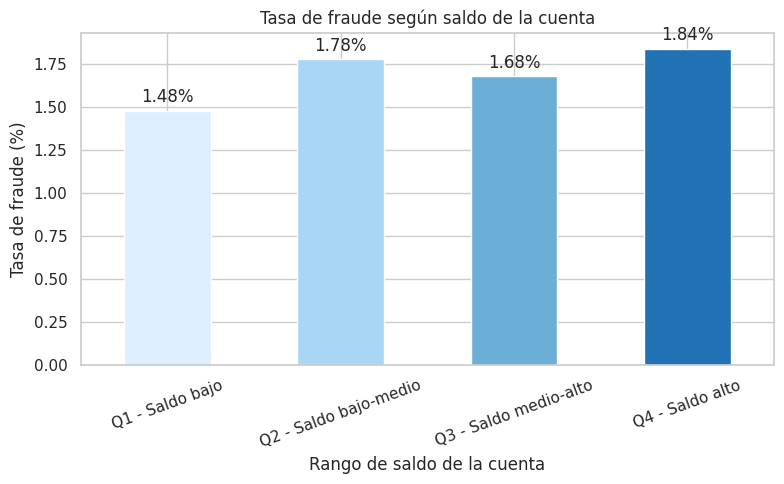

In [565]:
ax = tabla_balance_fraude['Tasa_fraude_%'].plot(
    kind='bar',
    figsize=(8,5),
    color=['#DCEEFF', '#A9D6F5', '#6BAED6', '#2171B5']
)

plt.xlabel('Rango de saldo de la cuenta')
plt.ylabel('Tasa de fraude (%)')
plt.title('Tasa de fraude según saldo de la cuenta')
plt.xticks(rotation=20)

# Etiquetas sobre las barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3
    )

plt.tight_layout()
plt.show()

El saldo de la cuenta presenta una asociación leve con la ocurrencia de fraude. Las cuentas ubicadas en el cuartil de saldo alto presentan la mayor tasa de fraude (1,84%), mientras que las de saldo bajo presentan la menor (1,48%). Sin embargo, las diferencias entre los rangos son reducidas, por lo que el saldo por sí solo no muestra una separación marcada entre transacciones fraudulentas y no fraudulentas.

## **20. Velocidad vs horas desde la última compra vs fraude**

El velocity_score muestra una diferencia más marcada entre transacciones fraudulentas y no fraudulentas, mientras que hours_since_last_txn presenta una diferencia más moderada. En conjunto, una mayor velocidad de transacciones y un menor tiempo desde la transacción anterior aparecen asociados con una mayor ocurrencia de fraude. Estos patrones son descriptivos y no implican causalidad.

In [566]:
#Resumen de la variable por fraude
df_fraude.groupby('is_fraud')[['velocity_score', 'hours_since_last_txn']].describe().round(2)

velocity_score                                             hours_since_last_txn                                            
                  count   mean    std  min    25%   50%   75%   max                count  mean   std   min   25%   50%    75%    max
is_fraud                                                                                                                            
False           19661.0  19.65  12.28  0.0  10.60  18.7  27.5  74.4              19661.0  8.98  8.85  0.01  2.61  6.23  12.48  87.05
True              339.0  28.97  13.71  0.0  18.45  27.7  37.7  71.5                339.0  7.01  7.64  0.01  1.52  4.27  10.00  48.12

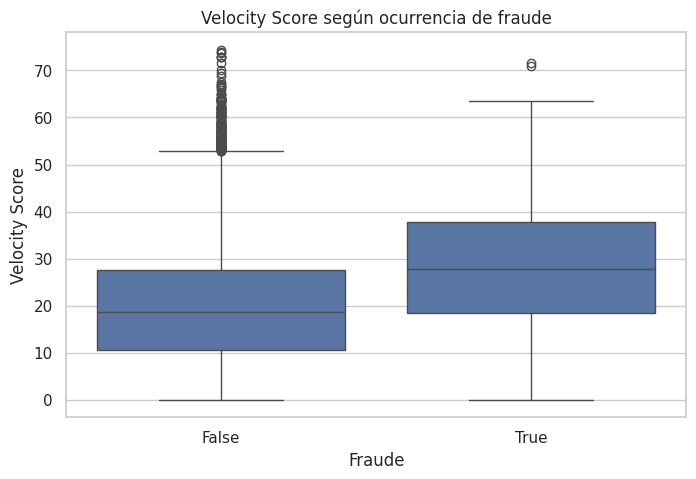

In [567]:
#Conparación visual
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_fraude,
    x='is_fraud',
    y='velocity_score'
)
plt.xlabel('Fraude')
plt.ylabel('Velocity Score')
plt.title('Velocity Score según ocurrencia de fraude')
plt.show()

El grupo de transacciones fraudulentas presenta valores de velocity_score generalmente más altos que las no fraudulentas. La mediana aumenta de 18,7 a 27,7 y el rango central también se desplaza hacia valores superiores. Esto sugiere una asociación entre una mayor velocidad de transacciones y la ocurrencia de fraude.

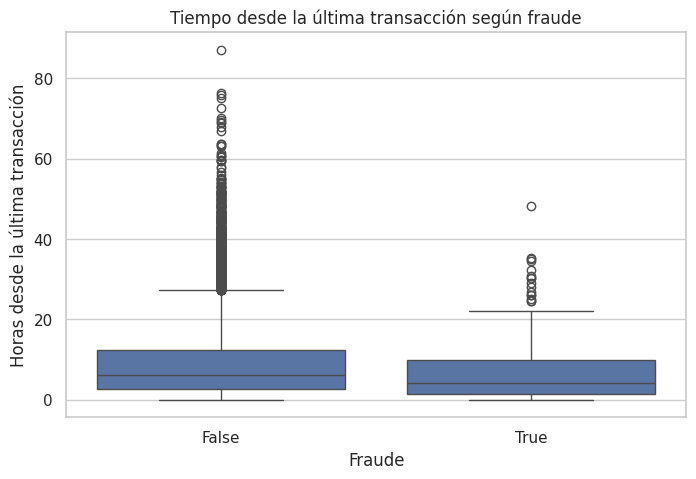

In [568]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_fraude,
    x='is_fraud',
    y='hours_since_last_txn'
)
plt.xlabel('Fraude')
plt.ylabel('Horas desde la última transacción')
plt.title('Tiempo desde la última transacción según fraude')
plt.show()

Las transacciones fraudulentas presentan un tiempo ligeramente menor desde la última transacción. La mediana pasa de 6,23 horas en las no fraudulentas a 4,27 horas en las fraudulentas. Esto indica que, en este conjunto de datos, las transacciones realizadas con menor intervalo respecto a la anterior muestran una mayor asociación con el fraude.

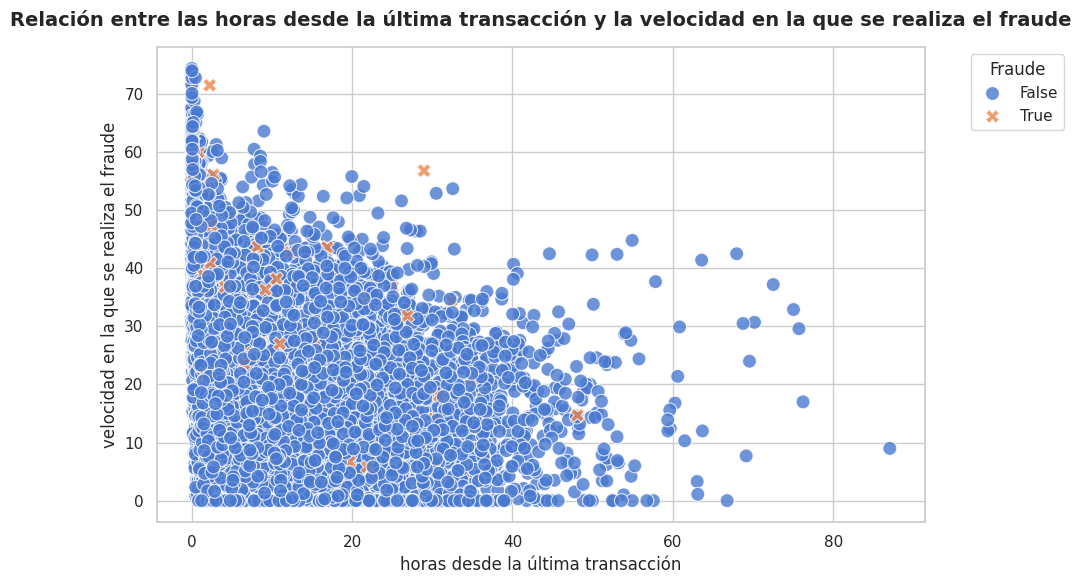

In [569]:
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data= df_fraude,
    x="hours_since_last_txn",
    y="velocity_score",
    hue="is_fraud",      # Color por especie
    style="is_fraud",    # Marcador diferente por especie
    s=100,              # Tamaño de los puntos
    alpha=0.8
)

# 4. Personalizar textos y diseño corporativo
plt.title("Relación entre las horas desde la última transacción y la velocidad en la que se realiza el fraude", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("horas desde la última transacción", fontsize=12)
plt.ylabel("velocidad en la que se realiza el fraude", fontsize=12)
plt.legend(title="Fraude", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar y mostrar limpio
plt.tight_layout()
plt.show()

El velocity_score muestra una diferencia más marcada entre transacciones fraudulentas y no fraudulentas, mientras que hours_since_last_txn presenta una diferencia más moderada. En conjunto, una mayor velocidad de transacciones y un menor tiempo desde la transacción anterior aparecen asociados con una mayor ocurrencia de fraude. Estos patrones son descriptivos y no implican causalidad.

## **21. Tipo de dispositivo vs Apoyo IA vs fraude**

La presencia de un intento de estafa generado o apoyado por IA se asocia con una mayor tasa de fraude en todos los tipos de dispositivo analizados. La diferencia es especialmente marcada en Android Phone, donde la tasa aumenta de 1,65% a 13,39%. Esto sugiere que combinar el tipo de dispositivo con esta variable puede aportar información relevante para la identificación temprana de transacciones potencialmente fraudulentas.

In [570]:
#Agrupamiento de variables

tabla_device_ia = pd.crosstab(
    [df_fraude['device_group'],
     df_fraude['is_ai_generated_scam_attempt']],
    df_fraude['is_fraud']
)

tabla_device_ia['Tasa_fraude_%'] = (
    tabla_device_ia[True] /
    tabla_device_ia.sum(axis=1) * 100
).round(2)

tabla_device_ia

is_fraud                                    False  True  Tasa_fraude_%
device_group  is_ai_generated_scam_attempt                            
Android Phone False                          5302    89           1.65
              True                             97    15          13.39
Otros         False                          4384    78           1.75
              True                             66     5           7.04
POS Terminal  False                          3051    50           1.61
              True                             57     4           6.56
Windows PC    False                          2548    25           0.97
              True                             46     4           8.00
iPhone        False                          4035    63           1.54
              True                             75     6           7.41

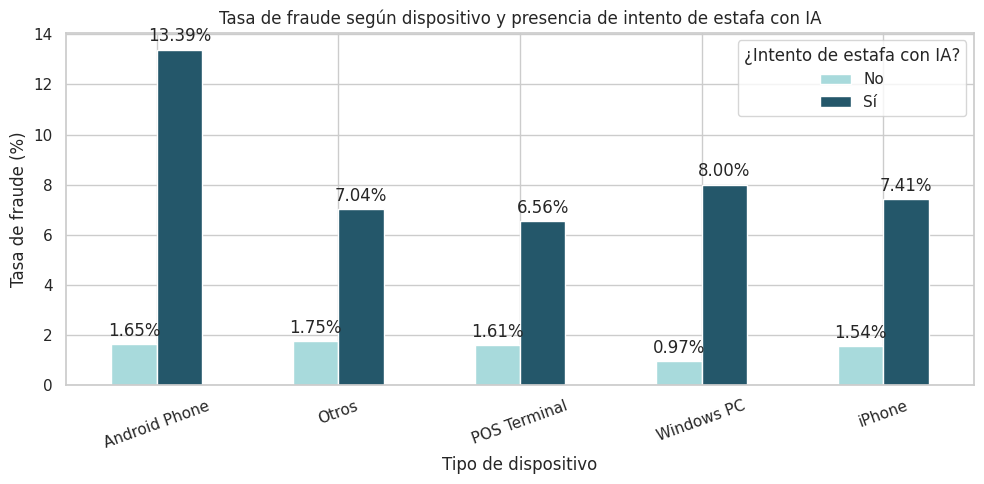

In [571]:
tabla_tasa_device_ia = (
    tabla_device_ia['Tasa_fraude_%']
    .unstack()
)

ax = tabla_tasa_device_ia.plot(
    kind='bar',
    figsize=(10,5),
    color=['#A8DADC', '#24576A']  # azul claro y azul oscuro
)

plt.xlabel('Tipo de dispositivo')
plt.ylabel('Tasa de fraude (%)')
plt.title('Tasa de fraude según dispositivo y presencia de intento de estafa con IA')
plt.xticks(rotation=20)

plt.legend(
    title='¿Intento de estafa con IA?',
    labels=['No', 'Sí']
)

# Etiquetas sobre cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3
    )

plt.tight_layout()
plt.show()

El patrón es bastante claro: en todos los tipos de dispositivo, la tasa de fraude es mayor cuando se identifica un intento de estafa con IA.

La presencia de un intento de estafa generado o apoyado por IA se asocia con una mayor tasa de fraude en todos los tipos de dispositivo analizados. La diferencia es especialmente marcada en Android Phone, donde la tasa aumenta de 1,65% a 13,39%. Esto sugiere que combinar el tipo de dispositivo con esta variable puede aportar información relevante para la identificación temprana de transacciones potencialmente fraudulentas.

**EXTRAER CSV**

In [572]:
df_fraude.to_csv("fraudes.csv", index=False)